# NASA Kepler Exoplanet Classification — Complete ML Workflow

This notebook implements a clean, leakage-safe machine learning workflow for multi-class classification of Kepler Objects of Interest (KOI) into three categories: CONFIRMED, CANDIDATE, and FALSE POSITIVE.

All preprocessing steps are embedded in sklearn Pipeline objects to prevent data leakage.

## Setup & Imports

In [118]:
import warnings
warnings.filterwarnings('ignore')

import os
import time
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from importlib import import_module

# Sklearn imports
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
from sklearn.datasets import make_moons
from types import SimpleNamespace

# Model imports
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier

# Try to import XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

# Try to import Optuna
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except Exception:
    OPTUNA_AVAILABLE = False

# Try to import Imbalanced-learn 
try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except Exception:
    SMOTE = None
    IMBLEARN_AVAILABLE = False

# Try to import SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

# ========== DEBUG MODE ==========
DEBUG_MODE = False

# Configuration
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

CLASS_ORDER = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

CLASS_PALETTE = {
    "CANDIDATE": "#F59E0B",       # yellow/orange
    "CONFIRMED": "#16A34A",       # green
    "FALSE POSITIVE": "#DC2626"   # red
}

CLASS_PALETTE_LIGHT = {
    "CANDIDATE": "#FDE68A",
    "CONFIRMED": "#BBF7D0",
    "FALSE POSITIVE": "#FECACA"
}

STAGE_PALETTE = {
    "Baseline": "#94A3B8",
    "Tuned": "#2563EB"
}

RESULT_PALETTE = {
    "Correct": "#16A34A",
    "Misclassified": "#DC2626"
}

class_stage_palettes = {
    class_name: {
        "Baseline": CLASS_PALETTE_LIGHT[class_name],
        "Tuned": CLASS_PALETTE[class_name]
    }
    for class_name in CLASS_ORDER
}

# Conditional settings based on DEBUG_MODE
if DEBUG_MODE:
    CV_SPLITS = 2
    print('⚠️ DEBUG_MODE is ON — Using reduced CV_SPLITS and search iterations')
else:
    CV_SPLITS = 5

# Load data
df = pd.read_csv('exoplanets_pull.csv')
print(f'✓ Dataset loaded: {df.shape}')

# Custom transformers for preprocessing

class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        return X_df.drop(columns=self.columns, errors='ignore')

class MedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.imputer = SimpleImputer(strategy='median')
        self.num_cols_ = None
    def fit(self, X, y=None):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.num_cols_ = X_df.select_dtypes(include=[np.number]).columns.tolist()
        if self.num_cols_:
            self.imputer.fit(X_df[self.num_cols_])
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        if self.num_cols_:
            X_df[self.num_cols_] = self.imputer.transform(X_df[self.num_cols_])
        return X_df

class LogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, skewed_cols):
        self.skewed_cols = skewed_cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        for col in self.skewed_cols:
            if col in X_df.columns:
                X_df[col] = np.log1p(X_df[col].clip(lower=0))
        return X_df

class OutlierClipper(BaseEstimator, TransformerMixin):
    """Clips outliers at training set percentiles only (fitted on train)"""
    def __init__(self, lower_q=0.01, upper_q=0.99):
        self.lower_q = lower_q
        self.upper_q = upper_q
        self.bounds_ = None
        self.num_cols_ = None
    def fit(self, X, y=None):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.num_cols_ = X_df.select_dtypes(include=[np.number]).columns.tolist()
        self.bounds_ = {}
        for col in self.num_cols_:
            self.bounds_[col] = (
                X_df[col].quantile(self.lower_q),
                X_df[col].quantile(self.upper_q)
            )
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        if self.bounds_:
            for col, (lower, upper) in self.bounds_.items():
                if col in X_df.columns:
                    X_df[col] = X_df[col].clip(lower=lower, upper=upper)
        return X_df

def build_preprocessing_pipeline(skewed_cols):
    """Build and return preprocessing steps (for flattening into a single Pipeline)."""
    steps = [
        ('drop', DropColumns(drop_cols)),
        ('imputer', MedianImputer()),
        ('log', LogTransformer(skewed_cols)),
        ('clip', OutlierClipper(lower_q=0.01, upper_q=0.99)),
        ('scaler', StandardScaler()),
    ]
    # SMOTE must be the last preprocessing step before the model so scaling finishes first.
    if IMBLEARN_AVAILABLE and SMOTE is not None:
        steps.append(('smote', SMOTE(random_state=42, k_neighbors=5)))
    return steps

print('✓ Preprocessing pipeline defined')
print('  Steps:')
print('    1. Drop columns (leakage + metadata)')
print('    2. Median imputation')
print('    3. Log1p transform for skewed features')
print('    4. Outlier clipping (fitted on train only)')
print('    5. Standard scaling')
print('    6. SMOTE (training data only, applied after scaling)')
print('\n  All transformers are fitted on train data only → prevents data leakage')

✓ Dataset loaded: (9564, 27)
✓ Preprocessing pipeline defined
  Steps:
    1. Drop columns (leakage + metadata)
    2. Median imputation
    3. Log1p transform for skewed features
    4. Outlier clipping (fitted on train only)
    5. Standard scaling
    6. SMOTE (training data only, applied after scaling)

  All transformers are fitted on train data only → prevents data leakage


## 1. EDA & Statistical Analysis

### 1.1 Dataset Overview

In [119]:
print('Dataset Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst few rows:')
display(df.head())

print('\nData types:')
display(df.dtypes.to_frame('dtype'))

Dataset Shape: (9564, 27)

Columns: ['kepid', 'kepoi_name', 'kepler_name', 'koi_disposition', 'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_tce_plnt_num', 'koi_tce_delivname', 'koi_steff', 'koi_slogg', 'koi_srad', 'ra', 'dec', 'koi_kepmag']

First few rows:


,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_tce_plnt_num,koi_tce_delivname,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,9.488036,170.538750,0.146,2.95750,615.8,2.26,793.0,93.59,35.8,1.0,q1_q17_dr25_tce,5455.0,4.467,0.927,291.93423,48.141651,15.347
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,54.418383,162.513840,0.586,4.50700,874.8,2.83,443.0,9.11,25.8,2.0,q1_q17_dr25_tce,5455.0,4.467,0.927,291.93423,48.141651,15.347
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,19.899140,175.850252,0.969,1.78220,10829.0,14.60,638.0,39.30,76.3,1.0,q1_q17_dr25_tce,5853.0,4.544,0.868,297.00482,48.134129,15.436
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,1.736952,170.307565,1.276,2.40641,8079.2,33.46,1395.0,891.96,505.6,1.0,q1_q17_dr25_tce,5805.0,4.564,0.791,285.53461,48.285210,15.597
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,2.525592,171.595550,0.701,1.65450,603.3,2.75,1406.0,926.16,40.9,1.0,q1_q17_dr25_tce,6031.0,4.438,1.046,288.75488,48.226200,15.509



Data types:


,dtype
kepid,int64
kepoi_name,object
kepler_name,object
koi_disposition,object
koi_pdisposition,object
koi_score,float64
koi_fpflag_nt,int64
koi_fpflag_ss,int64
koi_fpflag_co,int64
koi_fpflag_ec,int64


### 1.2 Missing Values

In [120]:
missing_report = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing Count', ascending=False)

print('Missing Values:')
display(missing_report[missing_report['Missing Count'] > 0])

Missing Values:


,Missing Count,Missing %
kepler_name,6817,71.28
koi_score,1510,15.79
koi_teq,363,3.80
koi_srad,363,3.80
koi_slogg,363,3.80
koi_steff,363,3.80
koi_model_snr,363,3.80
koi_impact,363,3.80
koi_depth,363,3.80
koi_prad,363,3.80


### 1.3 Descriptive Statistics

In [121]:
desc = df.describe().T
desc['median'] = df.median(numeric_only=True)
stats_table = desc[['mean', 'std', 'median', 'min', 'max']]
display(stats_table.round(3))

,mean,std,median,min,max
kepid,7690628.327,2653459.081,7906892.000,757450.000,1.293514e+07
koi_score,0.481,0.477,0.334,0.000,1.000000e+00
koi_fpflag_nt,0.209,4.767,0.000,0.000,4.650000e+02
koi_fpflag_ss,0.233,0.423,0.000,0.000,1.000000e+00
koi_fpflag_co,0.198,0.398,0.000,0.000,1.000000e+00
koi_fpflag_ec,0.120,0.325,0.000,0.000,1.000000e+00
koi_period,75.671,1334.744,9.753,0.242,1.299958e+05
koi_time0bk,166.183,67.919,137.225,120.516,1.472522e+03
koi_impact,0.735,3.349,0.537,0.000,1.008060e+02
koi_duration,5.622,6.472,3.793,0.052,1.385400e+02


### 1.4 Target Class Distribution

Target Class Distribution:
koi_disposition
CANDIDATE         1978
CONFIRMED         2747
FALSE POSITIVE    4839
Name: count, dtype: int64

Percentages:
koi_disposition
CANDIDATE         20.68
CONFIRMED         28.72
FALSE POSITIVE    50.60
Name: count, dtype: float64


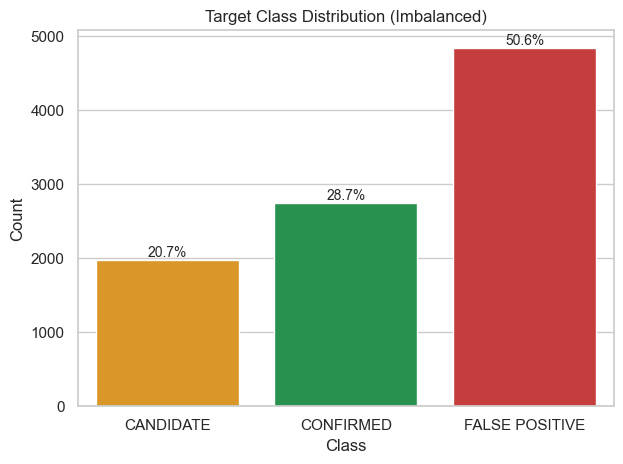


✓ The dataset is moderately imbalanced.
  → Stratified split is essential
  → Macro F1 is the main metric


In [122]:
target_col = 'koi_disposition'
target_counts = df[target_col].value_counts().reindex(CLASS_ORDER)
target_pct = (target_counts / len(df) * 100).round(2)

print('Target Class Distribution:')
print(target_counts)
print('\nPercentages:')
print(target_pct)

ax = sns.countplot(
    data=df,
    x=target_col,
    hue=target_col,
    order=CLASS_ORDER,
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE,
    legend=False
)
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    ax.annotate(f'{pct:.1f}%', (p.get_x() + p.get_width() / 2, count), 
                ha='center', va='bottom', fontsize=10)

plt.title('Target Class Distribution (Imbalanced)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('\n✓ The dataset is moderately imbalanced.')
print('  → Stratified split is essential')
print('  → Macro F1 is the main metric')

### 1.5 Feature Distributions and Skewness

In [123]:
# Identify leakage columns and metadata
leakage_cols = [
    'koi_pdisposition', 'koi_score', 'koi_fpflag_nt',
    'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec'
]
id_meta_cols = ['kepid', 'kepoi_name', 'kepler_name', 'koi_tce_delivname']
drop_cols = [target_col] + leakage_cols + id_meta_cols

X_eda = df.drop(columns=drop_cols).copy()
y_eda = df[target_col].copy()
numeric_cols = X_eda.select_dtypes(include='number').columns.tolist()

print(f'Features for EDA: {X_eda.shape[1]}')
print(f'Numeric features: {len(numeric_cols)}')

# Skewness analysis
skewness = X_eda[numeric_cols].skew().sort_values(ascending=False)
skewed_cols = skewness[skewness.abs() > 1].index.tolist()

print(f'\nHighly skewed features (|skewness| > 1): {len(skewed_cols)}')
print(skewed_cols)


Features for EDA: 16
Numeric features: 16

Highly skewed features (|skewness| > 1): 12
['koi_period', 'koi_prad', 'koi_insol', 'koi_impact', 'koi_srad', 'koi_duration', 'koi_model_snr', 'koi_depth', 'koi_time0bk', 'koi_tce_plnt_num', 'koi_teq', 'koi_slogg']


### 1.6 Correlation Matrix

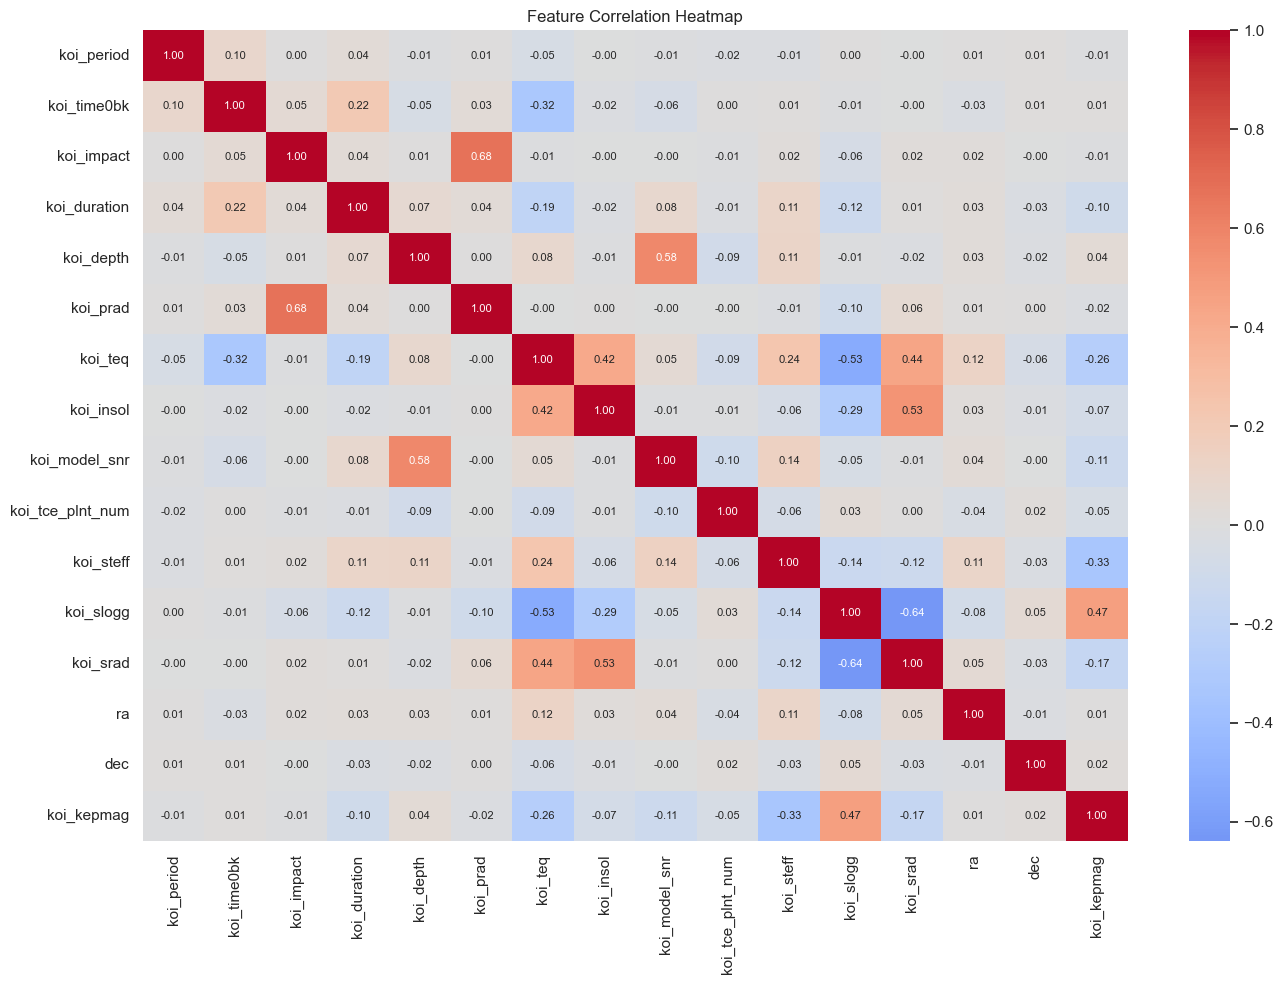

✓ No severe multicollinearity detected (no |r| > 0.85)


In [124]:
corr = X_eda[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Find feature pairs with high correlation (> 0.85)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.85:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

if high_corr_pairs:
    print('⚠️ High correlation pairs detected (|r| > 0.85):')
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f'  - {feat1} ↔ {feat2}: {corr_val:+.4f}')
else:
    print('✓ No severe multicollinearity detected (no |r| > 0.85)')

### 1.7 Feature vs Target Analysis

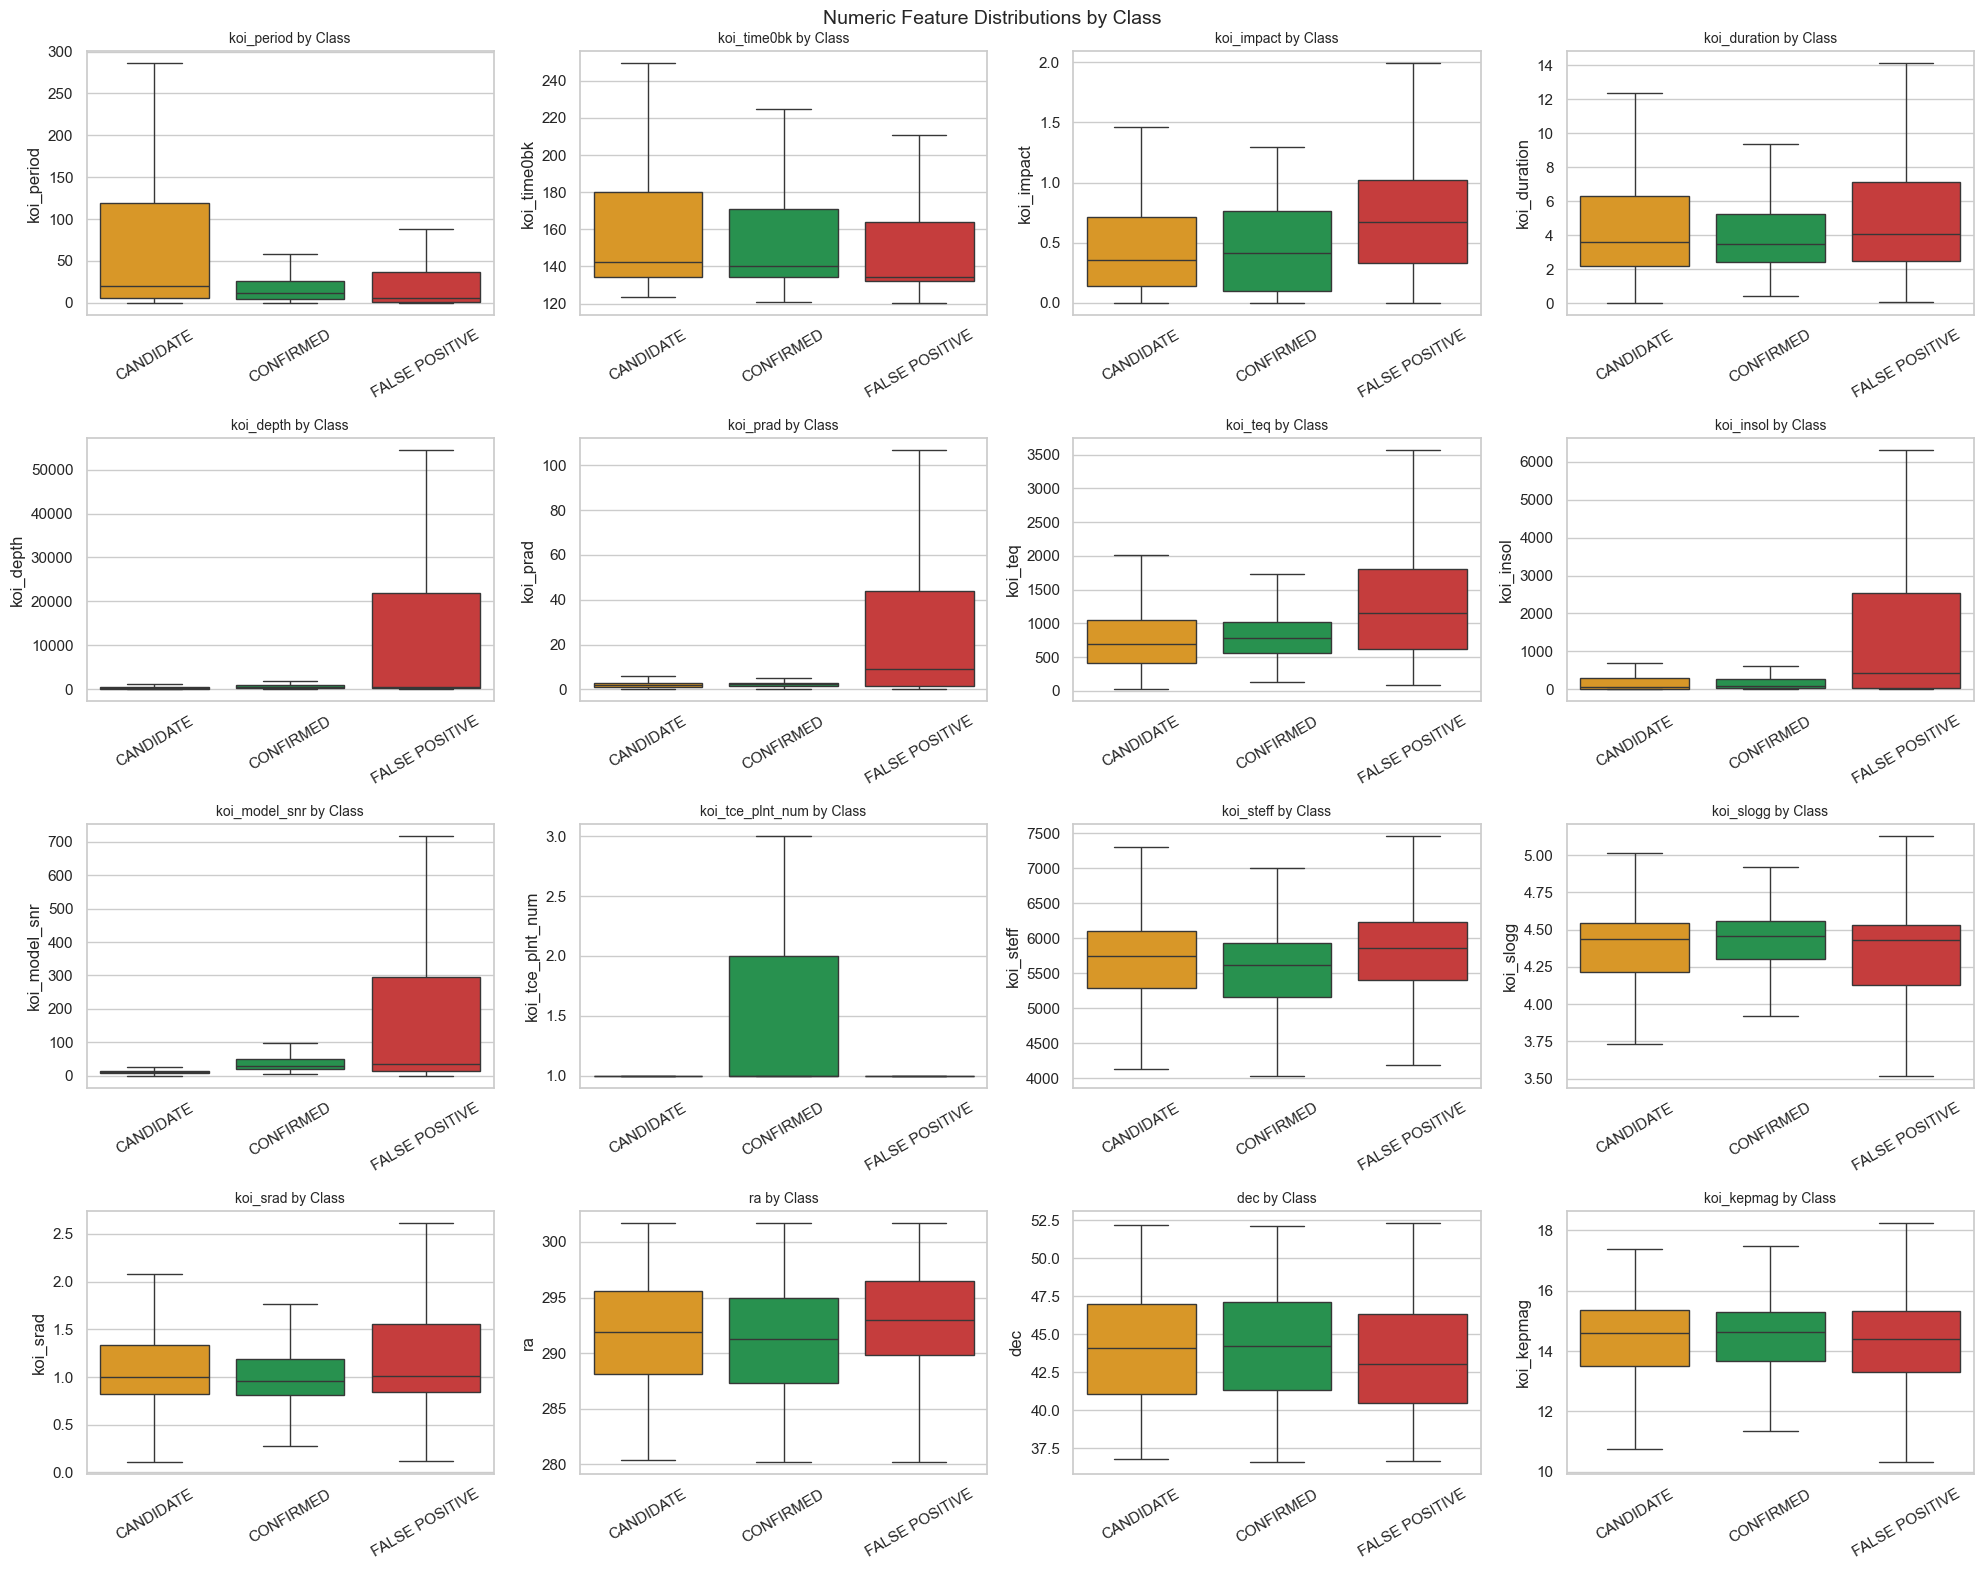

✓ Class-wise feature distribution analysis completed.
  → Boxplots show how each numeric feature varies across target classes.
  → Outliers are hidden to improve readability.
  → Overlapping boxes indicate features that may be harder to separate by class.


In [125]:
df_plot = X_eda.copy()
df_plot['target'] = y_eda

features_to_plot = numeric_cols

n_cols = 4
n_rows = int(np.ceil(len(features_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(
        x='target',
        y=col,
        data=df_plot,
        ax=axes[i],
        order=CLASS_ORDER,
        palette=CLASS_PALETTE,
        showfliers=False
    )
    axes[i].set_title(f'{col} by Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Numeric Feature Distributions by Class', fontsize=14)
plt.tight_layout()
plt.show()

print('✓ Class-wise feature distribution analysis completed.')
print('  → Boxplots show how each numeric feature varies across target classes.')
print('  → Outliers are hidden to improve readability.')
print('  → Overlapping boxes indicate features that may be harder to separate by class.')

## 2. Leakage Column Removal

In [126]:
print('Leakage columns (removed):')
for col in leakage_cols:
    print(f'  - {col}')

print('\nMetadata columns (removed):')
for col in id_meta_cols:
    print(f'  - {col}')

print(f'\nTarget column: {target_col}')
print(f'\nRemaining features: {len(numeric_cols)}')

Leakage columns (removed):
  - koi_pdisposition
  - koi_score
  - koi_fpflag_nt
  - koi_fpflag_ss
  - koi_fpflag_co
  - koi_fpflag_ec

Metadata columns (removed):
  - kepid
  - kepoi_name
  - kepler_name
  - koi_tce_delivname

Target column: koi_disposition

Remaining features: 16


## 3. Train-Test Split

In [127]:
# Prepare X and y
X = df.drop(columns=drop_cols)
y = df[target_col].copy()

# Stratified train-test split on raw labels (BEFORE encoding)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Fit LabelEncoder on training data only (after split)
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

train_pct = len(X_train) / len(df) * 100
test_pct = len(X_test) / len(df) * 100

print(f'Train set: {X_train.shape[0]} samples ({train_pct:.1f}%)')
print(f'Test set: {X_test.shape[0]} samples ({test_pct:.1f}%)')

print('\nClass distribution (train):')
for idx, cnt in pd.Series(y_train).value_counts(sort=False).items():
    pct = cnt / len(y_train) * 100
    print(f'  {le.classes_[idx]}: {cnt} ({pct:.1f}%)')

print('\nClass distribution (test):')
for idx, cnt in pd.Series(y_test).value_counts(sort=False).items():
    pct = cnt / len(y_test) * 100
    print(f'  {le.classes_[idx]}: {cnt} ({pct:.1f}%)')

print('\n✓ Stratified split successful — class proportions preserved')

Train set: 7651 samples (80.0%)
Test set: 1913 samples (20.0%)

Class distribution (train):
  FALSE POSITIVE: 3871 (50.6%)
  CANDIDATE: 1582 (20.7%)
  CONFIRMED: 2198 (28.7%)

Class distribution (test):
  FALSE POSITIVE: 968 (50.6%)
  CONFIRMED: 549 (28.7%)
  CANDIDATE: 396 (20.7%)

✓ Stratified split successful — class proportions preserved


## 3.5 Feature Engineering

Create ratio features that capture meaningful relationships between planetary characteristics. These ratios are engineered to provide additional predictive signals for exoplanet classification.

Added new ratio features to X_train and X_test:
['koi_prad_srad_ratio', 'koi_snr_depth_ratio', 'koi_insol_teq_ratio']
Skewness of new features (train):
{'koi_prad_srad_ratio': 26.763013063962376, 'koi_snr_depth_ratio': 5.930186954480733, 'koi_insol_teq_ratio': 34.71908297300231}
Updated numeric_cols length: 19
Updated skewed_cols length: 15


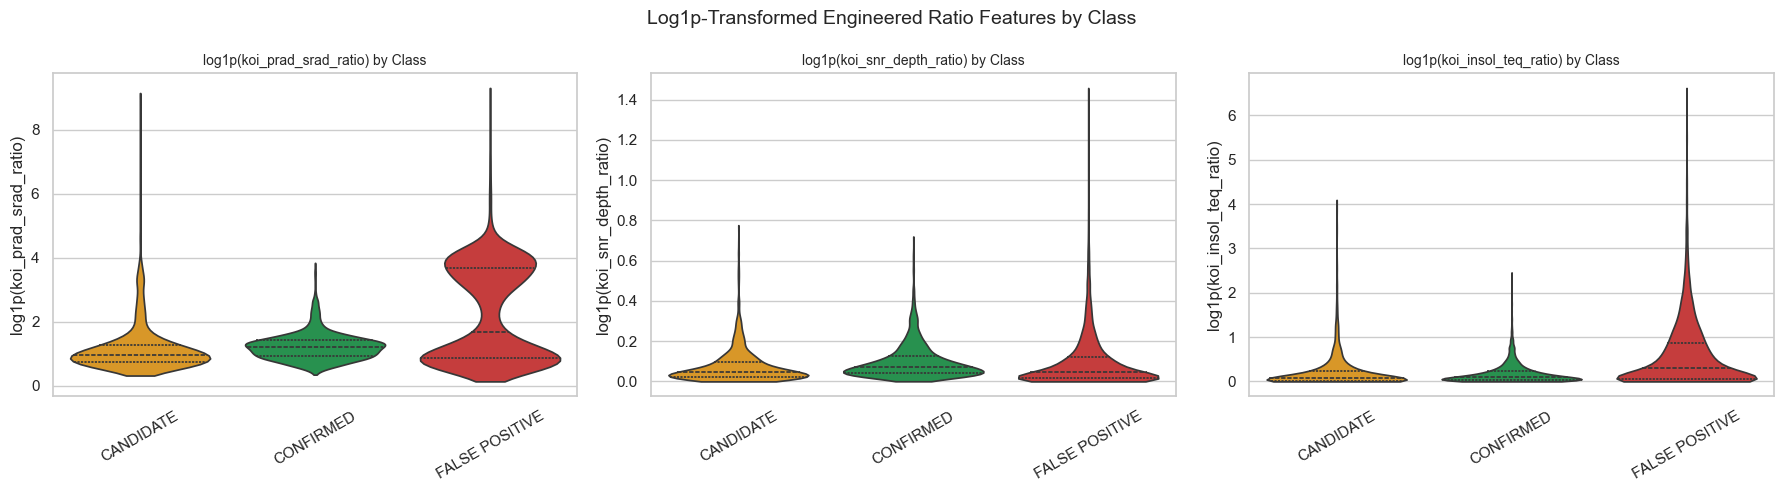

In [128]:
# === Feature Engineering: add ratio features to both train and test ===
new_cols = ["koi_prad_srad_ratio", "koi_snr_depth_ratio", "koi_insol_teq_ratio"]

# Create ratios on train
# koi_prad_srad_ratio: Planet radius relative to star radius (larger ratio = larger planet relative to its star)
X_train["koi_prad_srad_ratio"] = X_train['koi_prad'] / (X_train['koi_srad'] + 1e-6)

# koi_snr_depth_ratio: Signal-to-noise ratio relative to transit depth (higher = clearer transit signal)
X_train["koi_snr_depth_ratio"] = X_train['koi_model_snr'] / (X_train['koi_depth'] + 1e-6)

# koi_insol_teq_ratio: Insolation flux relative to equilibrium temperature (captures stellar energy impact)
X_train["koi_insol_teq_ratio"] = X_train['koi_insol'] / (X_train['koi_teq'] + 1e-6)

# Apply same transformations to test set (no leakage)
X_test["koi_prad_srad_ratio"] = X_test['koi_prad'] / (X_test['koi_srad'] + 1e-6)
X_test["koi_snr_depth_ratio"] = X_test['koi_model_snr'] / (X_test['koi_depth'] + 1e-6)
X_test["koi_insol_teq_ratio"] = X_test['koi_insol'] / (X_test['koi_teq'] + 1e-6)

# Update numeric_cols and skewed_cols based on train skewness
for c in new_cols:
    if c not in numeric_cols:
        numeric_cols.append(c)

# Check skewness on training data and add to skewed_cols if abs(skew) > 1
new_skew = X_train[new_cols].skew().abs()

for c, val in new_skew.items():
    if val > 1 and c not in skewed_cols:
        skewed_cols.append(c)

print('Added new ratio features to X_train and X_test:')
print(new_cols)
print('Skewness of new features (train):')
print(new_skew.to_dict())
print('Updated numeric_cols length:', len(numeric_cols))
print('Updated skewed_cols length:', len(skewed_cols))


# === Visualization: log1p-transformed engineered ratio features by class ===
df_ratio_plot = X_train[new_cols].copy()

for col in new_cols:
    df_ratio_plot[col] = np.log1p(df_ratio_plot[col].clip(lower=0))

df_ratio_plot["target"] = le.inverse_transform(y_train)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(new_cols):
    sns.violinplot(
        x="target",
        y=col,
        data=df_ratio_plot,
        ax=axes[i],
        order=CLASS_ORDER,
        palette=CLASS_PALETTE,
        inner="quartile",
        cut=0
    )
    axes[i].set_title(f"log1p({col}) by Class", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(f"log1p({col})")
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Log1p-Transformed Engineered Ratio Features by Class", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Preprocessing Pipeline

In [129]:
# Custom transformers for preprocessing

class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        return X_df.drop(columns=self.columns, errors='ignore')

class MedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.imputer = SimpleImputer(strategy='median')
        self.num_cols_ = None
    def fit(self, X, y=None):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.num_cols_ = X_df.select_dtypes(include=[np.number]).columns.tolist()
        if self.num_cols_:
            self.imputer.fit(X_df[self.num_cols_])
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        if self.num_cols_:
            X_df[self.num_cols_] = self.imputer.transform(X_df[self.num_cols_])
        return X_df

class LogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, skewed_cols):
        self.skewed_cols = skewed_cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        for col in self.skewed_cols:
            if col in X_df.columns:
                X_df[col] = np.log1p(X_df[col].clip(lower=0))
        return X_df

class OutlierClipper(BaseEstimator, TransformerMixin):
    """Clips outliers at training set percentiles only (fitted on train)"""
    def __init__(self, lower_q=0.01, upper_q=0.99):
        self.lower_q = lower_q
        self.upper_q = upper_q
        self.bounds_ = None
        self.num_cols_ = None
    def fit(self, X, y=None):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.num_cols_ = X_df.select_dtypes(include=[np.number]).columns.tolist()
        self.bounds_ = {}
        for col in self.num_cols_:
            self.bounds_[col] = (
                X_df[col].quantile(self.lower_q),
                X_df[col].quantile(self.upper_q)
            )
        return self
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        if self.bounds_:
            for col, (lower, upper) in self.bounds_.items():
                if col in X_df.columns:
                    X_df[col] = X_df[col].clip(lower=lower, upper=upper)
        return X_df

def build_preprocessing_pipeline(skewed_cols):
    """Build and return preprocessing steps (for flattening into a single Pipeline)."""
    steps = [
        ('drop',    DropColumns(drop_cols)),
        ('imputer', MedianImputer()),
        ('log',     LogTransformer(skewed_cols)),
        ('clip',    OutlierClipper(lower_q=0.01, upper_q=0.99)),
        ('scaler',  StandardScaler()),
    ]
    # SMOTE must be the last preprocessing step before the model so scaling finishes first.
    if IMBLEARN_AVAILABLE and SMOTE is not None:
        steps.append(('smote', SMOTE(random_state=42, k_neighbors=5)))
    return steps

print('✓ Preprocessing pipeline defined')
print('  Steps:')
print('    1. Drop columns (leakage + metadata)')
print('    2. Median imputation')
print('    3. Log1p transform for skewed features')
print('    4. Outlier clipping (fitted on train only)')
print('    5. Standard scaling')
print('\n  All transformers are fitted on train data only → prevents data leakage')

✓ Preprocessing pipeline defined
  Steps:
    1. Drop columns (leakage + metadata)
    2. Median imputation
    3. Log1p transform for skewed features
    4. Outlier clipping (fitted on train only)
    5. Standard scaling

  All transformers are fitted on train data only → prevents data leakage


### 4.1 Preprocessing Preview

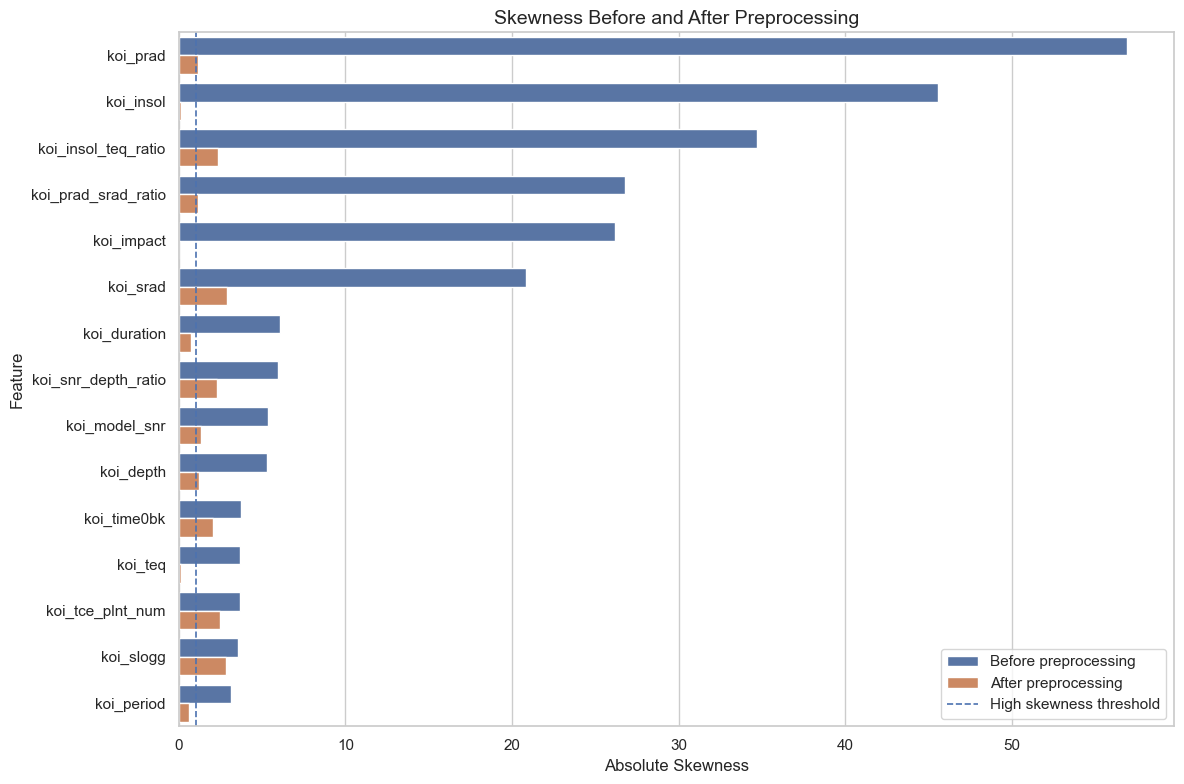

,Before preprocessing,After preprocessing,Reduction (%)
koi_impact,26.194556,0.023270,99.91
koi_insol,45.568982,0.108455,99.76
koi_prad,56.886836,1.175047,97.93
koi_teq,3.698448,0.098344,97.34
koi_prad_srad_ratio,26.763013,1.121497,95.81
koi_insol_teq_ratio,34.719083,2.324586,93.30
koi_duration,6.071626,0.743653,87.75
koi_srad,20.860341,2.873948,86.22
koi_period,3.134611,0.599531,80.87
koi_depth,5.302507,1.217552,77.04


✓ Skewness comparison completed.
  → The plot shows how log1p transformation and clipping reduce feature skewness.
  → Reduction (%) quantifies how much skewness decreased after preprocessing.
  → SMOTE is excluded because it changes the number of samples.
  → Actual preprocessing is still performed inside each model pipeline.


In [130]:
# === 4.1 Preprocessing Preview: Skewness before vs after preprocessing ===
# This preview is only for visualization.
# The actual preprocessing is still applied inside each model pipeline.

preprocessing_steps_no_smote = [
    step for step in build_preprocessing_pipeline(skewed_cols)
    if step[0] != 'smote'
]

preprocessor_preview = Pipeline(preprocessing_steps_no_smote)
X_train_processed = preprocessor_preview.fit_transform(X_train, y_train)

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=X_train.columns,
    index=X_train.index
)

skew_before = X_train[numeric_cols].skew().abs()
skew_after = X_train_processed_df[numeric_cols].skew().abs()

skew_compare = pd.DataFrame({
    'Before preprocessing': skew_before,
    'After preprocessing': skew_after
})

skew_compare['Reduction (%)'] = (
    (skew_compare['Before preprocessing'] - skew_compare['After preprocessing'])
    / skew_compare['Before preprocessing']
    * 100
).round(2)

skew_compare = skew_compare.sort_values('Before preprocessing', ascending=False).head(15)

# Long format for seaborn barplot
skew_plot_df = skew_compare[['Before preprocessing', 'After preprocessing']].reset_index()
skew_plot_df = skew_plot_df.rename(columns={'index': 'Feature'})
skew_plot_df = skew_plot_df.melt(
    id_vars='Feature',
    var_name='Stage',
    value_name='Absolute Skewness'
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=skew_plot_df,
    x='Absolute Skewness',
    y='Feature',
    hue='Stage'
)

plt.axvline(1, linestyle='--', linewidth=1.2, label='High skewness threshold')
plt.title('Skewness Before and After Preprocessing', fontsize=14)
plt.xlabel('Absolute Skewness')
plt.ylabel('Feature')
plt.legend()
plt.tight_layout()
plt.show()

# Display reduction table
display(
    skew_compare[['Before preprocessing', 'After preprocessing', 'Reduction (%)']]
    .sort_values('Reduction (%)', ascending=False)
)

print('✓ Skewness comparison completed.')
print('  → The plot shows how log1p transformation and clipping reduce feature skewness.')
print('  → Reduction (%) quantifies how much skewness decreased after preprocessing.')
print('  → SMOTE is excluded because it changes the number of samples.')
print('  → Actual preprocessing is still performed inside each model pipeline.')

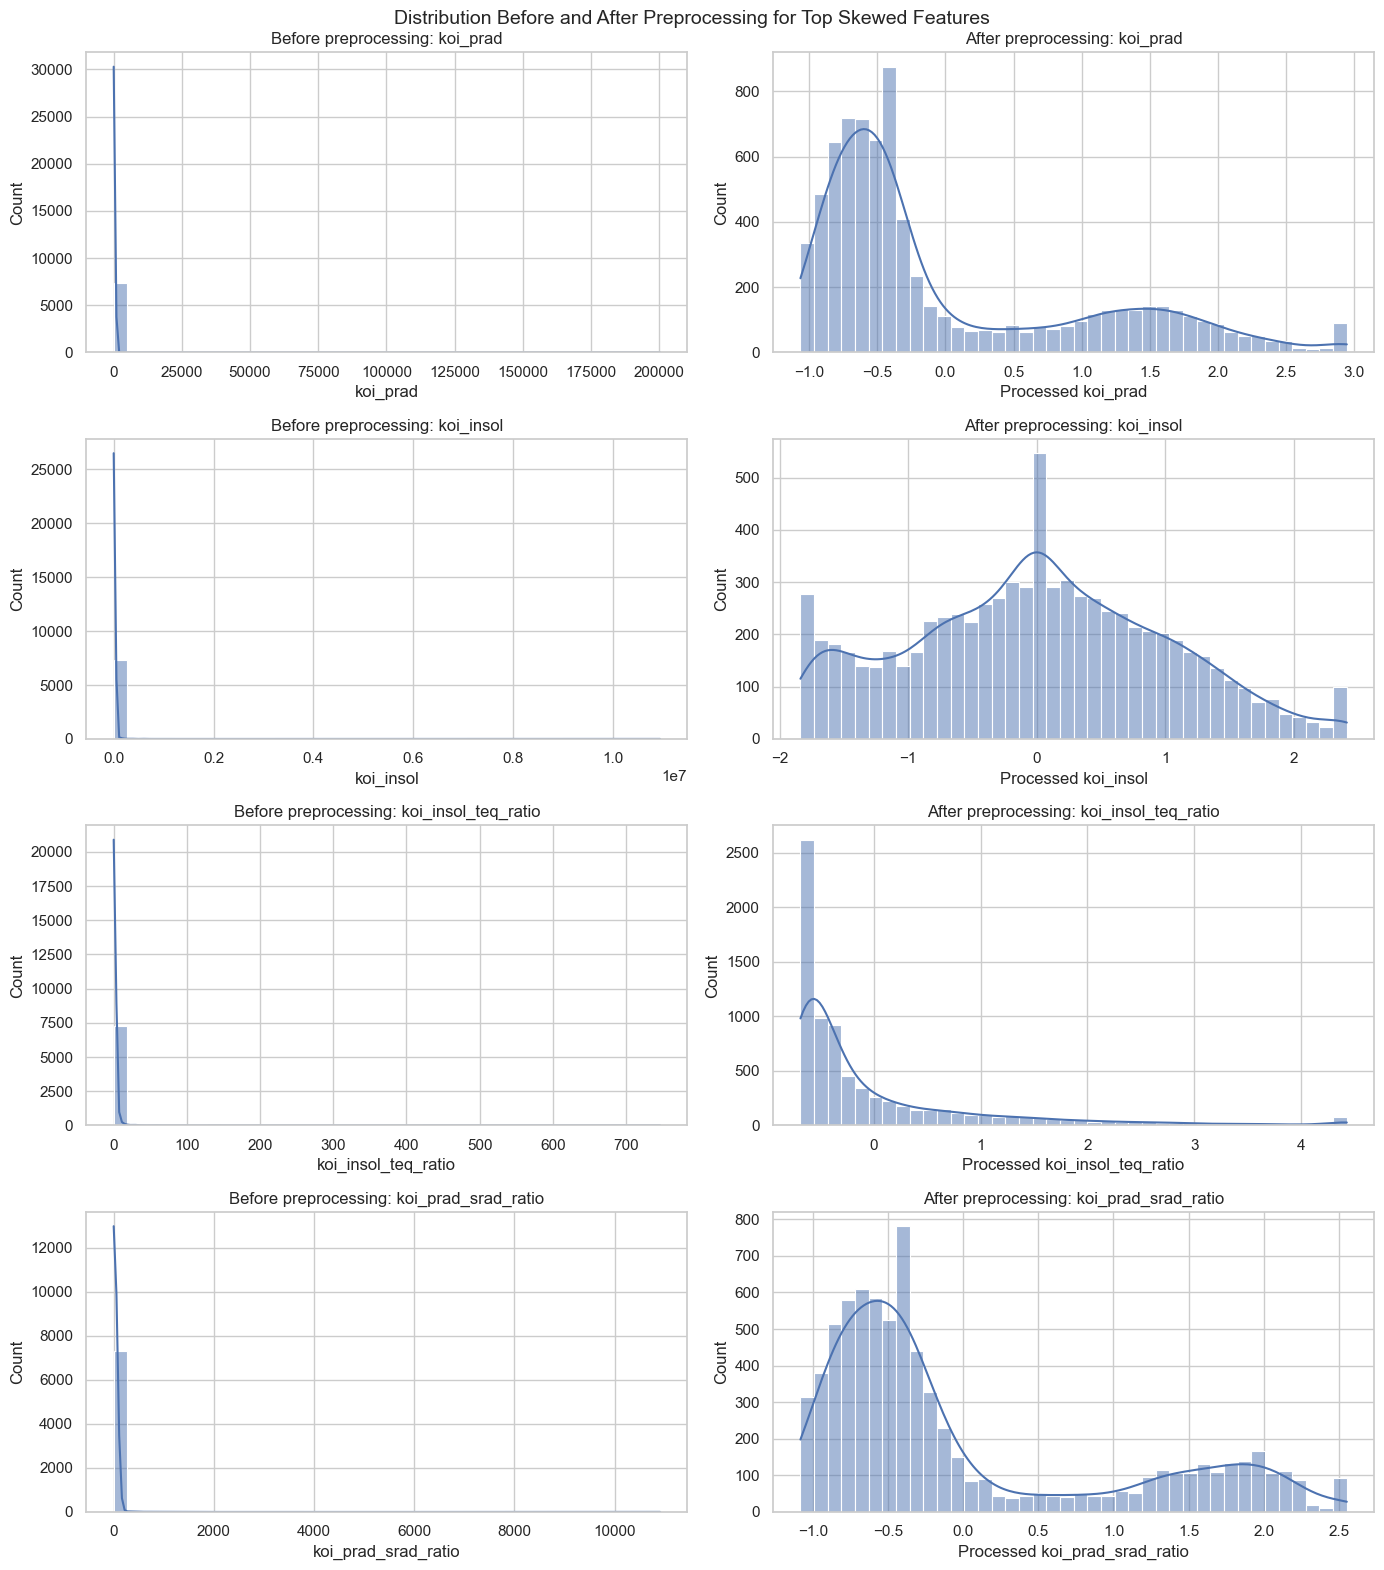

✓ Distribution comparison completed.
  → Histograms show how preprocessing changes the shape of highly skewed feature distributions.
  → Only the top 4 most skewed features are shown to keep the visualization readable.
  → Actual preprocessing is still performed inside each model pipeline.


In [131]:
# === 4.1 Preprocessing Preview: Distribution before vs after preprocessing ===
# This preview is only for visualization.
# The actual preprocessing is still applied inside each model pipeline.

top_skewed_features = skew_compare.index[:4].tolist()

fig, axes = plt.subplots(len(top_skewed_features), 2, figsize=(14, 4 * len(top_skewed_features)))

for i, col in enumerate(top_skewed_features):
    sns.histplot(
        X_train[col].dropna(),
        bins=40,
        kde=True,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Before preprocessing: {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')

    sns.histplot(
        X_train_processed_df[col].dropna(),
        bins=40,
        kde=True,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'After preprocessing: {col}')
    axes[i, 1].set_xlabel(f'Processed {col}')
    axes[i, 1].set_ylabel('Count')

plt.suptitle('Distribution Before and After Preprocessing for Top Skewed Features', fontsize=14)
plt.tight_layout()
plt.show()

print('✓ Distribution comparison completed.')
print('  → Histograms show how preprocessing changes the shape of highly skewed feature distributions.')
print('  → Only the top 4 most skewed features are shown to keep the visualization readable.')
print('  → Actual preprocessing is still performed inside each model pipeline.')

## 5. Baseline Models

### Evaluation Helper Functions

In [132]:
# Helper functions for evaluation

def evaluate_model(model_name, y_true, y_pred):
    """Evaluate model and return metrics"""
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Weighted F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

def plot_confusion_matrix(y_true, y_pred, model_name, class_names):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Count'}
    )
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def print_classification_report(y_true, y_pred, class_names):
    """Print detailed classification report"""
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

# Store baseline and tuned results
baseline_results = []
tuned_results = []

print('Ready to train baseline models')

Ready to train baseline models


### 5.1 Logistic Regression Baseline

BASELINE: Logistic Regression

Training and prediction time: 0.32 seconds

Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.47      0.74      0.58       396
     CONFIRMED       0.74      0.78      0.76       549
FALSE POSITIVE       0.90      0.66      0.76       968

      accuracy                           0.71      1913
     macro avg       0.70      0.73      0.70      1913
  weighted avg       0.76      0.71      0.72      1913



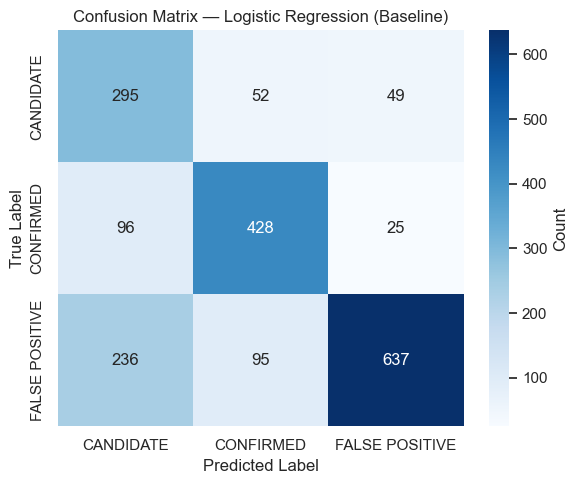

✓ Baseline results stored


In [133]:
print('=' * 60)
print('BASELINE: Logistic Regression')
print('=' * 60)

lr_baseline = Pipeline(
    build_preprocessing_pipeline(skewed_cols) +
    [('model', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))]
)

start_time = time.time()

lr_baseline.fit(X_train, y_train)
y_pred_lr = lr_baseline.predict(X_test)

elapsed_time = time.time() - start_time

print(f'\nTraining and prediction time: {elapsed_time:.2f} seconds')

print('\nClassification Report:')
print_classification_report(y_test, y_pred_lr, le.classes_)

plot_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression (Baseline)', le.classes_)

baseline_results.append(evaluate_model('Logistic Regression (Baseline)', y_test, y_pred_lr))
print('✓ Baseline results stored')

### 5.2 Decision Tree Baseline

BASELINE: Decision Tree

Training and prediction time: 0.52 seconds

Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.42      0.49      0.45       396
     CONFIRMED       0.75      0.69      0.72       549
FALSE POSITIVE       0.77      0.75      0.76       968

      accuracy                           0.68      1913
     macro avg       0.65      0.65      0.65      1913
  weighted avg       0.69      0.68      0.69      1913



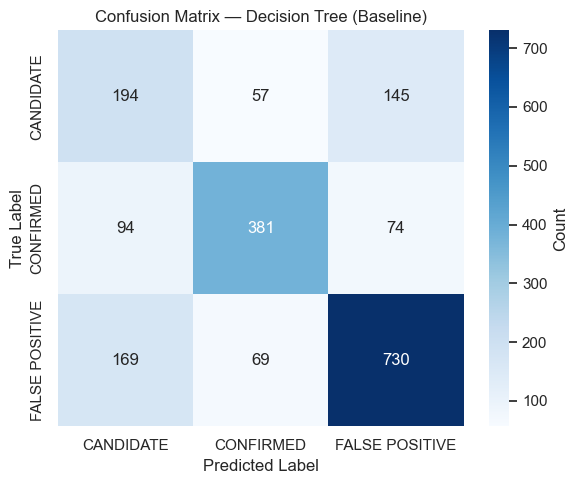

✓ Baseline results stored


In [134]:
print('=' * 60)
print('BASELINE: Decision Tree')
print('=' * 60)

dt_baseline = Pipeline(
    build_preprocessing_pipeline(skewed_cols) +
    [('model', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))]
)

start_time = time.time()

dt_baseline.fit(X_train, y_train)
y_pred_dt = dt_baseline.predict(X_test)

elapsed_time = time.time() - start_time
print(f'\nTraining and prediction time: {elapsed_time:.2f} seconds')

print('\nClassification Report:')
print_classification_report(y_test, y_pred_dt, le.classes_)

plot_confusion_matrix(y_test, y_pred_dt, 'Decision Tree (Baseline)', le.classes_)

baseline_results.append(evaluate_model('Decision Tree (Baseline)', y_test, y_pred_dt))
print('✓ Baseline results stored')

### 5.3 Random Forest Baseline

BASELINE: Random Forest

Training and prediction time: 1.43 seconds

Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.52      0.65      0.58       396
     CONFIRMED       0.81      0.82      0.82       549
FALSE POSITIVE       0.87      0.77      0.82       968

      accuracy                           0.76      1913
     macro avg       0.73      0.75      0.74      1913
  weighted avg       0.78      0.76      0.77      1913



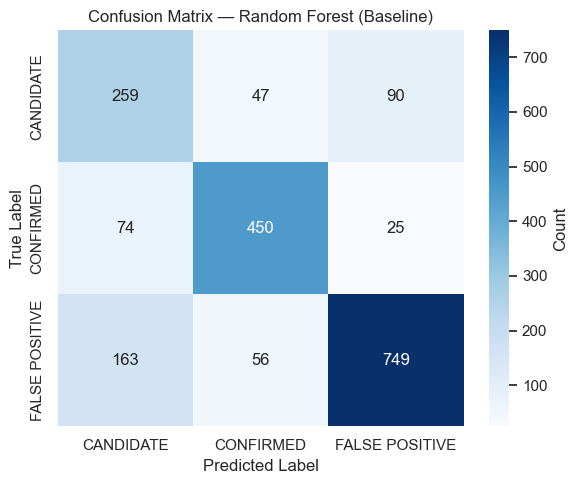

✓ Baseline results stored


In [135]:
print('=' * 60)
print('BASELINE: Random Forest')
print('=' * 60)

# Conditional n_estimators based on DEBUG_MODE
rf_n_estimators = 50 if DEBUG_MODE else 100

rf_baseline = Pipeline(
    build_preprocessing_pipeline(skewed_cols) +
    [('model', RandomForestClassifier(
        n_estimators=rf_n_estimators,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced'
    ))]
)

start_time = time.time()

rf_baseline.fit(X_train, y_train)
y_pred_rf = rf_baseline.predict(X_test)

elapsed_time = time.time() - start_time
print(f'\nTraining and prediction time: {elapsed_time:.2f} seconds')

print('\nClassification Report:')
print_classification_report(y_test, y_pred_rf, le.classes_)

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest (Baseline)', le.classes_)

baseline_results.append(evaluate_model('Random Forest (Baseline)', y_test, y_pred_rf))
print('✓ Baseline results stored')

### 5.4 XGBoost Baseline

BASELINE: XGBoost

Training and prediction time: 0.85 seconds

Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.54      0.73      0.62       396
     CONFIRMED       0.81      0.84      0.83       549
FALSE POSITIVE       0.90      0.75      0.82       968

      accuracy                           0.77      1913
     macro avg       0.75      0.78      0.76      1913
  weighted avg       0.80      0.77      0.78      1913



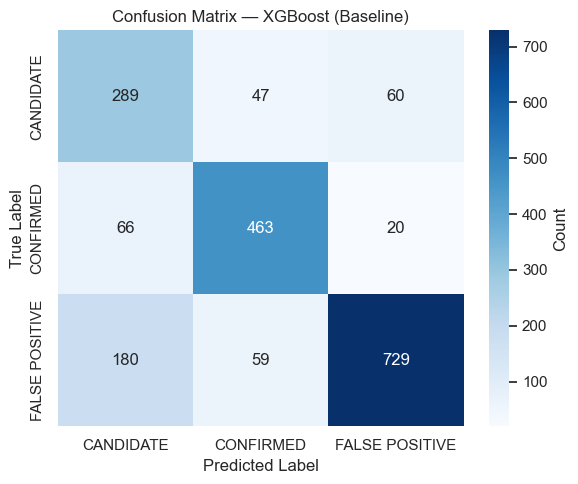

✓ Baseline results stored


In [136]:
if XGBOOST_AVAILABLE:
    print('=' * 60)
    print('BASELINE: XGBoost')
    print('=' * 60)

    # Conditional n_estimators based on DEBUG_MODE
    xgb_n_estimators = 50 if DEBUG_MODE else 100

    xgb_baseline = Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', XGBClassifier(
            objective='multi:softprob',
            num_class=len(le.classes_),
            n_estimators=xgb_n_estimators,
            learning_rate=0.1,
            max_depth=5,
            random_state=RANDOM_STATE,
            eval_metric='mlogloss',
            verbosity=0
        ))]
    )

    start_time = time.time()

    xgb_baseline.fit(X_train, y_train)
    y_pred_xgb = xgb_baseline.predict(X_test)

    elapsed_time = time.time() - start_time
    print(f'\nTraining and prediction time: {elapsed_time:.2f} seconds')

    print('\nClassification Report:')
    print_classification_report(y_test, y_pred_xgb, le.classes_)

    plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost (Baseline)', le.classes_)

    baseline_results.append(evaluate_model('XGBoost (Baseline)', y_test, y_pred_xgb))
    print('✓ Baseline results stored')

else:
    print('⚠️ XGBoost not available. Skipping XGBoost baseline.')
    xgb_baseline = None

### 5.5 SVM RBF Baseline

BASELINE: SVM (RBF kernel)

Training and prediction time: 2.85 seconds

Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.47      0.74      0.58       396
     CONFIRMED       0.82      0.80      0.81       549
FALSE POSITIVE       0.90      0.71      0.79       968

      accuracy                           0.74      1913
     macro avg       0.73      0.75      0.73      1913
  weighted avg       0.79      0.74      0.75      1913



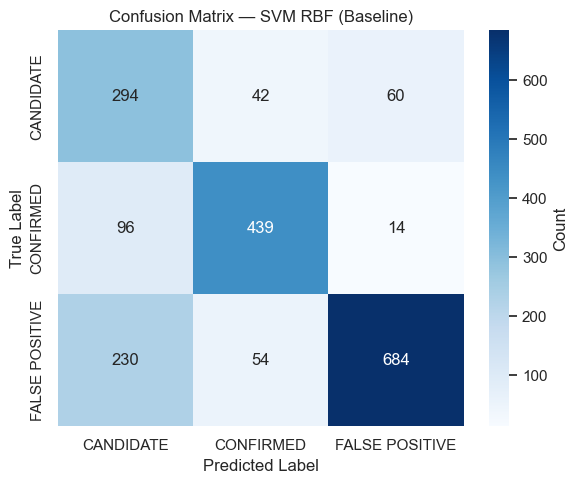

✓ Baseline results stored


In [137]:
print('=' * 60)
print('BASELINE: SVM (RBF kernel)')
print('=' * 60)

svm_baseline = Pipeline(
    build_preprocessing_pipeline(skewed_cols) +
    [('model', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))]
)

start_time = time.time()

svm_baseline.fit(X_train, y_train)
y_pred_svm = svm_baseline.predict(X_test)

elapsed_time = time.time() - start_time
print(f'\nTraining and prediction time: {elapsed_time:.2f} seconds')

print('\nClassification Report:')
print_classification_report(y_test, y_pred_svm, le.classes_)

plot_confusion_matrix(y_test, y_pred_svm, 'SVM RBF (Baseline)', le.classes_)

baseline_results.append(evaluate_model('SVM RBF (Baseline)', y_test, y_pred_svm))
print('✓ Baseline results stored')

### 5.5 Stacking Classifier


BASELINE: Stacking Classifier

Training and prediction time: 44.28 seconds

Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.50      0.74      0.60       396
     CONFIRMED       0.84      0.82      0.83       549
FALSE POSITIVE       0.90      0.74      0.81       968

      accuracy                           0.76      1913
     macro avg       0.75      0.77      0.75      1913
  weighted avg       0.80      0.76      0.77      1913



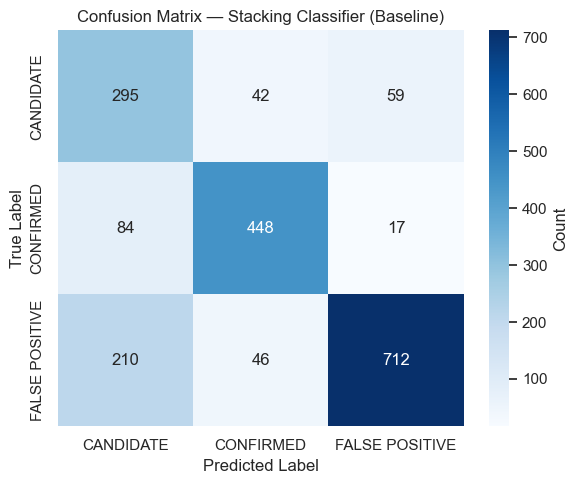

✓ Baseline stacking results stored


In [138]:
print('\n' + '=' * 60)
print('BASELINE: Stacking Classifier')
print('=' * 60)

# Base estimators for stacking
stack_estimators = []

if XGBOOST_AVAILABLE:
    stack_estimators.append((
        'xgb',
        Pipeline(
            build_preprocessing_pipeline(skewed_cols) +
            [('model', XGBClassifier(
                objective='multi:softprob',
                num_class=len(le.classes_),
                n_estimators=50 if DEBUG_MODE else 100,
                learning_rate=0.1,
                max_depth=5,
                random_state=RANDOM_STATE,
                eval_metric='mlogloss',
                verbosity=0
            ))]
        )
    ))
else:
    print('⚠️ XGBoost not available — skipping XGB in stacking')

stack_estimators.append((
    'rf',
    Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', RandomForestClassifier(
            n_estimators=50 if DEBUG_MODE else 100,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight='balanced'
        ))]
    )
))

stack_estimators.append((
    'svm',
    Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            class_weight='balanced',
            probability=True,
            random_state=RANDOM_STATE
        ))]
    )
))

if len(stack_estimators) >= 2:
    stacking_baseline = StackingClassifier(
        estimators=stack_estimators,
        final_estimator=LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        cv=2 if DEBUG_MODE else 5,
        n_jobs=-1
    )

    start_time = time.time()

    stacking_baseline.fit(X_train, y_train)
    y_pred_stack_baseline = stacking_baseline.predict(X_test)

    elapsed_time = time.time() - start_time
    print(f'\nTraining and prediction time: {elapsed_time:.2f} seconds')

    print('\nClassification Report:')
    print_classification_report(y_test, y_pred_stack_baseline, le.classes_)

    plot_confusion_matrix(
        y_test,
        y_pred_stack_baseline,
        'Stacking Classifier (Baseline)',
        le.classes_
    )

    baseline_results.append(
        evaluate_model(
            'Stacking Classifier (Baseline)',
            y_test,
            y_pred_stack_baseline
        )
    )

    print('✓ Baseline stacking results stored')

else:
    print('⚠️ Not enough base estimators available to build stacking model')

## 6. Baseline Model Comparison

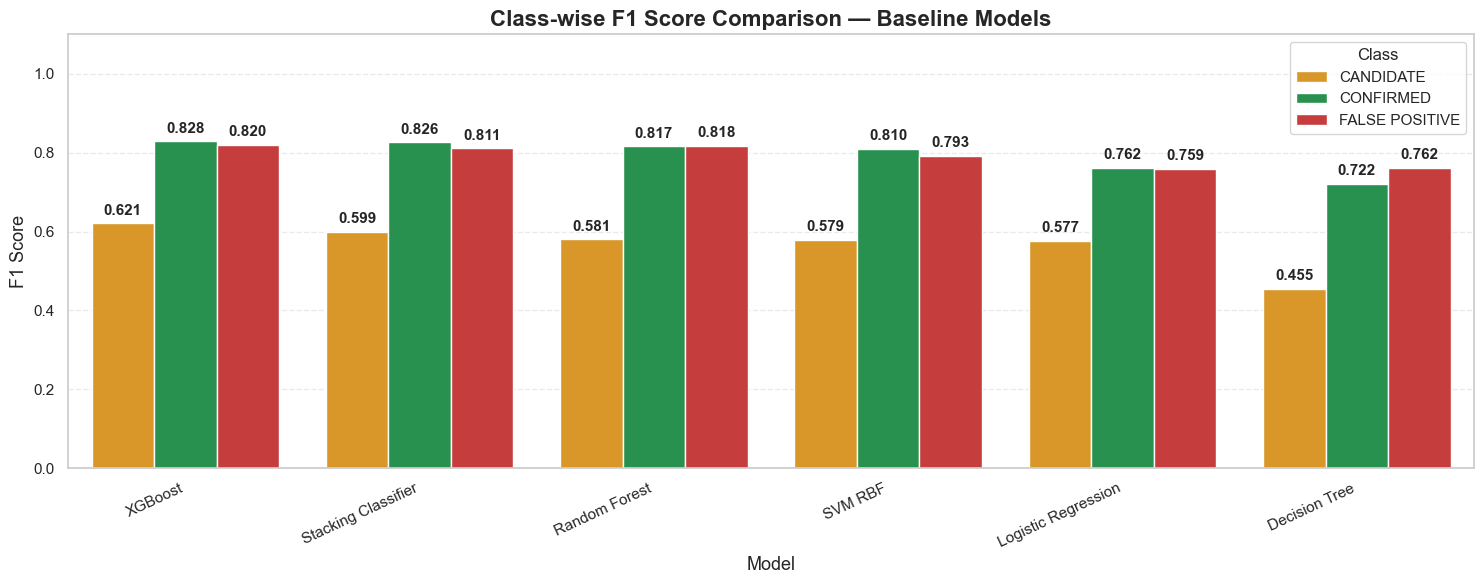

In [139]:
# === Class-wise F1 comparison for baseline models ===

baseline_predictions = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'SVM RBF': y_pred_svm
}

if XGBOOST_AVAILABLE and 'y_pred_xgb' in globals():
    baseline_predictions['XGBoost'] = y_pred_xgb

if 'y_pred_stack_baseline' in globals():
    baseline_predictions['Stacking Classifier'] = y_pred_stack_baseline
else:
    print('⚠️ Stacking baseline predictions not found. Run the Stacking baseline cell first.')

class_f1_rows = []

for model_name, y_pred in baseline_predictions.items():
    f1_per_class = f1_score(
        y_test,
        y_pred,
        average=None,
        labels=np.arange(len(le.classes_)),
        zero_division=0
    )
    
    for class_name, f1_val in zip(CLASS_ORDER, f1_per_class):
        class_f1_rows.append({
            'Model': model_name,
            'Class': class_name,
            'F1 Score': f1_val
        })

class_f1_df = pd.DataFrame(class_f1_rows)

# Rebuild clean baseline_df if needed
baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.drop_duplicates(subset='Model', keep='last')
baseline_df = baseline_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

# Create model order from cleaned baseline_df
model_order = (
    baseline_df['Model']
    .str.replace(' \\(Baseline\\)', '', regex=True)
    .tolist()
)

# Keep only models that actually exist in class_f1_df
model_order = [m for m in model_order if m in class_f1_df['Model'].unique()]

plt.figure(figsize=(15, 6))

ax = sns.barplot(
    data=class_f1_df,
    x='Model',
    y='F1 Score',
    hue='Class',
    order=model_order,
    hue_order=CLASS_ORDER,
    palette=CLASS_PALETTE
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=4,
        fontsize=11,
        fontweight='bold'
    )

plt.title('Class-wise F1 Score Comparison — Baseline Models', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=13)
plt.ylabel('F1 Score', fontsize=13)
plt.ylim(0, 1.10)
plt.xticks(rotation=25, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title='Class', title_fontsize=12, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Hyperparameter Optimization

In [140]:
# Define shared cross-validation strategy
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print('Cross-Validation Strategy: StratifiedKFold')
print(f'  - Splits: {CV_SPLITS}')
print(f'  - Shuffle: True')
print(f'  - Random state: {RANDOM_STATE}')
print('\nScoring metric: f1_macro')
print('\nNote: X_test is NOT used during hyperparameter tuning')
print('      Tuned models are evaluated on the held-out X_test after hyperparameter tuning.')

Cross-Validation Strategy: StratifiedKFold
  - Splits: 5
  - Shuffle: True
  - Random state: 42

Scoring metric: f1_macro

Note: X_test is NOT used during hyperparameter tuning
      Tuned models are evaluated on the held-out X_test after hyperparameter tuning.


### 7.1 Logistic Regression — GridSearchCV


TUNING: Logistic Regression (GridSearchCV)
Fitting 5 folds for each of 83 candidates, totalling 415 fits

Tuning time: 55.53 seconds

Best parameters:
  - C: 3
  - l1_ratio: 0.1
  - penalty: elasticnet
  - solver: saga
Best CV F1 (macro): 0.6867
Test Set Macro F1: 0.6982
Gap (CV - Test): -0.0115

Test Set Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.47      0.74      0.58       396
     CONFIRMED       0.75      0.78      0.76       549
FALSE POSITIVE       0.89      0.66      0.76       968

      accuracy                           0.71      1913
     macro avg       0.70      0.73      0.70      1913
  weighted avg       0.76      0.71      0.72      1913



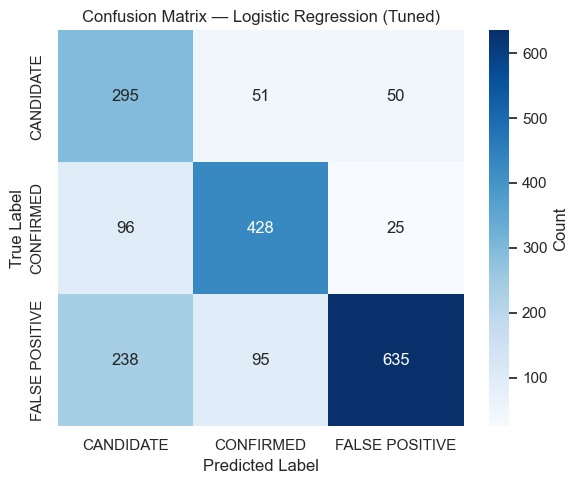

✓ Tuned results stored


In [141]:
print('\n' + '=' * 60)
print('TUNING: Logistic Regression (GridSearchCV)')
print('=' * 60)

# Conditional param_grid based on DEBUG_MODE
if DEBUG_MODE:
    lr_param_grid = {
        'model__C': [0.01],
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs'],
    }
else:
    lr_param_grid = [
        {
            'model__C': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
            'model__penalty': ['l2'],
            'model__solver': ['lbfgs', 'liblinear'],
        },

        {
            'model__C': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
            'model__penalty': ['l1'],
            'model__solver': ['liblinear'],
        },
        {
            'model__C': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30],
            'model__penalty': ['elasticnet'],
            'model__solver': ['saga'],
            'model__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
        }

    ]

lr_search = GridSearchCV(
    estimator=Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE))]
    ),
    param_grid=lr_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()

lr_search.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f'\nTuning time: {elapsed_time:.2f} seconds')

print('\nBest parameters:')
for param, value in lr_search.best_params_.items():
    clean_param = param.replace('model__', '')
    print(f'  - {clean_param}: {value}')
print(f'Best CV F1 (macro): {lr_search.best_score_:.4f}')

# Evaluate on test set
y_pred_lr_tuned = lr_search.best_estimator_.predict(X_test)
test_f1_lr_tuned = f1_score(y_test, y_pred_lr_tuned, average='macro', zero_division=0)

# CV vs Test comparison
print(f'Test Set Macro F1: {test_f1_lr_tuned:.4f}')
cv_test_gap = lr_search.best_score_ - test_f1_lr_tuned
print(f'Gap (CV - Test): {cv_test_gap:+.4f}')

if abs(cv_test_gap) > 0.03:
    print(f'⚠️ WARNING: Large gap detected (>{0.03:.2f}) — possible instability or overfitting')

print('\nTest Set Classification Report:')
print_classification_report(y_test, y_pred_lr_tuned, le.classes_)

plot_confusion_matrix(y_test, y_pred_lr_tuned, 'Logistic Regression (Tuned)', le.classes_)

tuned_results.append(evaluate_model('Logistic Regression (Tuned)', y_test, y_pred_lr_tuned))
print('✓ Tuned results stored')

### 7.2 Decision Tree — GridSearchCV


TUNING: Decision Tree (GridSearchCV)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Tuning time: 25.95 seconds

Best parameters:
  - criterion: gini
  - max_depth: 10
  - min_samples_leaf: 20
  - min_samples_split: 2
Best CV F1 (macro): 0.7137
Test Set Macro F1: 0.7098
Gap (CV - Test): +0.0039

Test Set Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.48      0.65      0.55       396
     CONFIRMED       0.77      0.82      0.79       549
FALSE POSITIVE       0.87      0.71      0.78       968

      accuracy                           0.73      1913
     macro avg       0.71      0.73      0.71      1913
  weighted avg       0.76      0.73      0.74      1913



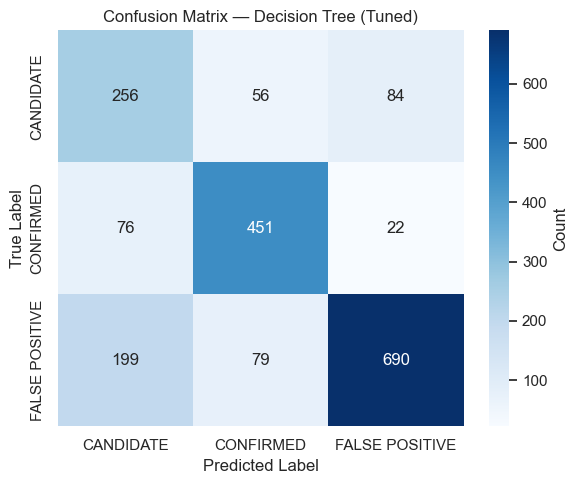

✓ Tuned results stored


In [142]:
print('\n' + '=' * 60)
print('TUNING: Decision Tree (GridSearchCV)')
print('=' * 60)

# Conditional param_grid based on DEBUG_MODE
if DEBUG_MODE:
    dt_param_grid = {
        'model__max_depth': [5],
        'model__min_samples_split': [2],
        'model__min_samples_leaf': [1],
        'model__criterion': ['gini'],
    }
else:
    dt_param_grid = {
        'model__max_depth': [5, 8, 10, 12, 15],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [5, 10, 15, 20],
        'model__criterion': ['gini', 'entropy'],
    }

dt_search = GridSearchCV(
    estimator=Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))]
    ),
    param_grid=dt_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()

dt_search.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f'\nTuning time: {elapsed_time:.2f} seconds')

print('\nBest parameters:')
for param, value in dt_search.best_params_.items():
    clean_param = param.replace('model__', '')
    print(f'  - {clean_param}: {value}')
print(f'Best CV F1 (macro): {dt_search.best_score_:.4f}')

# Evaluate on test set
y_pred_dt_tuned = dt_search.best_estimator_.predict(X_test)
test_f1_dt_tuned = f1_score(y_test, y_pred_dt_tuned, average='macro', zero_division=0)

# CV vs Test comparison
print(f'Test Set Macro F1: {test_f1_dt_tuned:.4f}')
cv_test_gap = dt_search.best_score_ - test_f1_dt_tuned
print(f'Gap (CV - Test): {cv_test_gap:+.4f}')

if abs(cv_test_gap) > 0.03:
    print(f'⚠️ WARNING: Large gap detected (>{0.03:.2f}) — possible instability or overfitting')

print('\nTest Set Classification Report:')
print_classification_report(y_test, y_pred_dt_tuned, le.classes_)

plot_confusion_matrix(y_test, y_pred_dt_tuned, 'Decision Tree (Tuned)', le.classes_)

tuned_results.append(evaluate_model('Decision Tree (Tuned)', y_test, y_pred_dt_tuned))
print('✓ Tuned results stored')

### 7.3 Random Forest — RandomizedSearchCV


TUNING: Random Forest (RandomizedSearchCV, n_iter=40)
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Tuning time: 524.37 seconds

Best parameters:
  - n_estimators: 800
  - min_samples_split: 10
  - min_samples_leaf: 2
  - max_features: log2
  - max_depth: None
  - bootstrap: False

Best CV F1 (macro): 0.7553
Test Set Macro F1: 0.7394
Gap (CV - Test): +0.0159

Test Set Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.52      0.64      0.57       396
     CONFIRMED       0.83      0.82      0.83       549
FALSE POSITIVE       0.86      0.78      0.82       968

      accuracy                           0.76      1913
     macro avg       0.74      0.75      0.74      1913
  weighted avg       0.78      0.76      0.77      1913



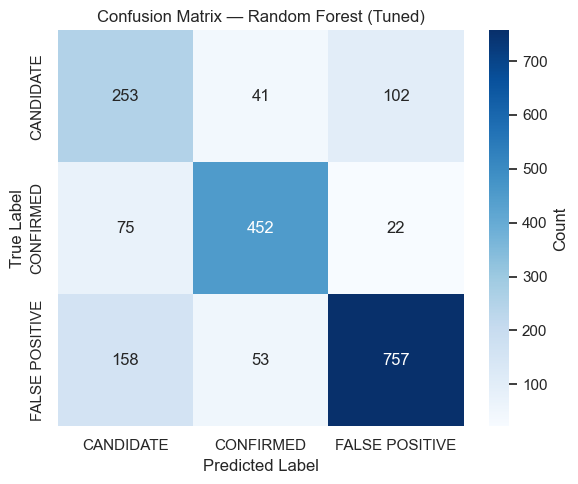

✓ Tuned results stored


In [143]:
print('\n' + '=' * 60)
print('TUNING: Random Forest (RandomizedSearchCV, n_iter=40)')
print('=' * 60)

# Conditional n_iter and param_grid based on DEBUG_MODE
rf_n_iter = 3 if DEBUG_MODE else 40

if DEBUG_MODE:
    rf_param_grid = {
        'model__n_estimators': [50],
        'model__max_depth': [None],
        'model__min_samples_split': [2],
        'model__min_samples_leaf': [1],
        'model__max_features': ['sqrt'],
        'model__bootstrap': [True],
    }
else:
    rf_param_grid = {
        'model__n_estimators': [100, 200, 400, 600, 800],
        'model__max_depth': [None, 5, 10, 20, 30, 50],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf': [1, 2, 4, 8],
        'model__max_features': ['sqrt', 'log2'],
        'model__bootstrap': [True, False],
    }

rf_search = RandomizedSearchCV(
    estimator=Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,
            class_weight='balanced'
        ))]
    ),
    param_distributions=rf_param_grid,
    n_iter=rf_n_iter,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

start_time = time.time()

rf_search.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f'\nTuning time: {elapsed_time:.2f} seconds')

print('\nBest parameters:')
for param, value in rf_search.best_params_.items():
    clean_param = param.replace('model__', '')
    print(f'  - {clean_param}: {value}')

print(f'\nBest CV F1 (macro): {rf_search.best_score_:.4f}')

# Evaluate on test set
y_pred_rf_tuned = rf_search.best_estimator_.predict(X_test)
test_f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average='macro', zero_division=0)

# CV vs Test comparison
print(f'Test Set Macro F1: {test_f1_rf_tuned:.4f}')
cv_test_gap = rf_search.best_score_ - test_f1_rf_tuned
print(f'Gap (CV - Test): {cv_test_gap:+.4f}')

if abs(cv_test_gap) > 0.03:
    print(f'⚠️ WARNING: Large gap detected (>{0.03:.2f}) — possible instability or overfitting')

print('\nTest Set Classification Report:')
print_classification_report(y_test, y_pred_rf_tuned, le.classes_)

plot_confusion_matrix(y_test, y_pred_rf_tuned, 'Random Forest (Tuned)', le.classes_)

tuned_results.append(evaluate_model('Random Forest (Tuned)', y_test, y_pred_rf_tuned))
print('✓ Tuned results stored')

### 7.4 XGBoost — Optuna Optimization (n_trials=50)


TUNING: XGBoost (Optuna)

Tuning time: 349.14 seconds

Best Optuna CV F1 (macro): 0.7670

Best parameters:
  - n_estimators: 700
  - max_depth: 8
  - learning_rate: 0.12475146219429756
  - subsample: 0.8326739905134763
  - colsample_bytree: 0.6114115017098533
  - gamma: 0.15448232757889319
  - reg_alpha: 2.709082082015443
  - reg_lambda: 5.1194326313194365
  - min_child_weight: 4

Test Set Macro F1: 0.7560
Gap (CV - Test): +0.0110

Test Set Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.54      0.66      0.59       396
     CONFIRMED       0.84      0.83      0.83       549
FALSE POSITIVE       0.88      0.80      0.84       968

      accuracy                           0.78      1913
     macro avg       0.75      0.76      0.76      1913
  weighted avg       0.80      0.78      0.79      1913



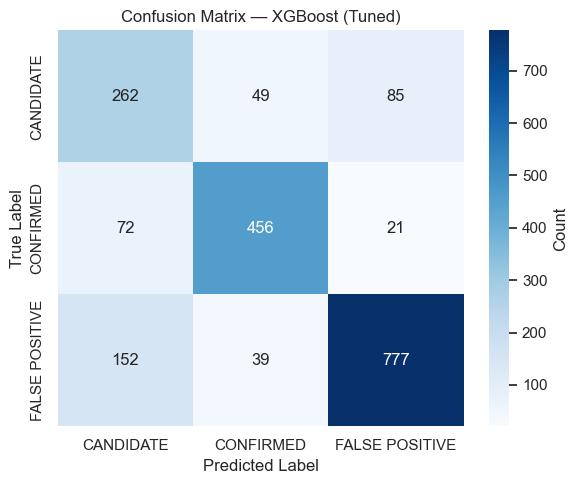

✓ Tuned results stored


In [144]:
if XGBOOST_AVAILABLE and OPTUNA_AVAILABLE:
    print('\n' + '=' * 60)
    print('TUNING: XGBoost (Optuna)')
    print('=' * 60)

    # 50 is already solid; 75 gives Optuna more room to explore the wider search space.
    n_trials = 5 if DEBUG_MODE else 75

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_categorical(
                'n_estimators',
                [200, 300, 500, 700, 1000]
            ) if not DEBUG_MODE else 200,

            'max_depth': trial.suggest_int(
                'max_depth',
                2, 10
            ) if not DEBUG_MODE else 2,

            'learning_rate': trial.suggest_float(
                'learning_rate',
                0.005, 0.15,
                log=True
            ) if not DEBUG_MODE else 0.005,

            'subsample': trial.suggest_float(
                'subsample',
                0.6, 1.0
            ) if not DEBUG_MODE else 0.6,

            'colsample_bytree': trial.suggest_float(
                'colsample_bytree',
                0.6, 1.0
            ) if not DEBUG_MODE else 0.6,

            'gamma': trial.suggest_float(
                'gamma',
                0.0, 5.0
            ) if not DEBUG_MODE else 0.0,

            'reg_alpha': trial.suggest_float(
                'reg_alpha',
                0.0, 5.0
            ) if not DEBUG_MODE else 0.0,

            'reg_lambda': trial.suggest_float(
                'reg_lambda',
                0.5, 15.0
            ) if not DEBUG_MODE else 0.5,

            'min_child_weight': trial.suggest_int(
                'min_child_weight',
                1, 10
            ) if not DEBUG_MODE else 1,
        }

        estimator = Pipeline(
            build_preprocessing_pipeline(skewed_cols) +
            [('model', XGBClassifier(
                objective='multi:softprob',
                num_class=len(le.classes_),
                random_state=RANDOM_STATE,
                eval_metric='mlogloss',
                verbosity=0,
                n_jobs=1,  # avoid nested parallelism; cross_val_score handles parallelism
                **params
            ))]
        )

        scores = cross_val_score(
            estimator,
            X_train,
            y_train,
            scoring='f1_macro',
            cv=cv,
            n_jobs=-1
        )

        return scores.mean()

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='maximize', sampler=sampler)

    start_time = time.time()

    study.optimize(objective, n_trials=n_trials)

    elapsed_time = time.time() - start_time
    print(f'\nTuning time: {elapsed_time:.2f} seconds')

    print(f'\nBest Optuna CV F1 (macro): {study.best_value:.4f}')

    print('\nBest parameters:')
    for param, value in study.best_params.items():
        print(f'  - {param}: {value}')

    best_params = study.best_params.copy()

    xgb_pipeline = Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', XGBClassifier(
            objective='multi:softprob',
            num_class=len(le.classes_),
            random_state=RANDOM_STATE,
            eval_metric='mlogloss',
            verbosity=0,
            n_jobs=1,
            **best_params
        ))]
    )

    xgb_pipeline.fit(X_train, y_train)
    y_pred_xgb_tuned = xgb_pipeline.predict(X_test)

    test_f1_xgb_tuned = f1_score(
        y_test,
        y_pred_xgb_tuned,
        average='macro',
        zero_division=0
    )

    print(f'\nTest Set Macro F1: {test_f1_xgb_tuned:.4f}')
    cv_test_gap = study.best_value - test_f1_xgb_tuned
    print(f'Gap (CV - Test): {cv_test_gap:+.4f}')

    if abs(cv_test_gap) > 0.03:
        print(f'⚠️ WARNING: Large gap detected (>{0.03:.2f}) — possible instability or overfitting')

    print('\nTest Set Classification Report:')
    print_classification_report(y_test, y_pred_xgb_tuned, le.classes_)

    plot_confusion_matrix(y_test, y_pred_xgb_tuned, 'XGBoost (Tuned)', le.classes_)

    tuned_results.append(evaluate_model('XGBoost (Tuned)', y_test, y_pred_xgb_tuned))

    xgb_search = SimpleNamespace(
        best_estimator_=xgb_pipeline,
        best_score_=study.best_value,
        best_params_=best_params
    )

    print('✓ Tuned results stored')

elif XGBOOST_AVAILABLE and not OPTUNA_AVAILABLE:
    print('⚠️ Optuna not available. Skipping XGBoost Optuna tuning.')
    xgb_search = None

else:
    print('⚠️ XGBoost not available. Skipping XGBoost tuning.')
    xgb_search = None

### 7.5 SVM RBF — GridSearchCV


TUNING: SVM RBF (GridSearchCV)
Fitting 5 folds for each of 49 candidates, totalling 245 fits

Tuning time: 171.61 seconds

Best parameters:
  - C: 10
  - gamma: auto
  - kernel: rbf

Best CV F1 (macro): 0.7369
Test Set Macro F1: 0.7270
Gap (CV - Test): +0.0098

Test Set Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.48      0.69      0.56       396
     CONFIRMED       0.82      0.80      0.81       549
FALSE POSITIVE       0.89      0.74      0.81       968

      accuracy                           0.75      1913
     macro avg       0.73      0.74      0.73      1913
  weighted avg       0.78      0.75      0.76      1913



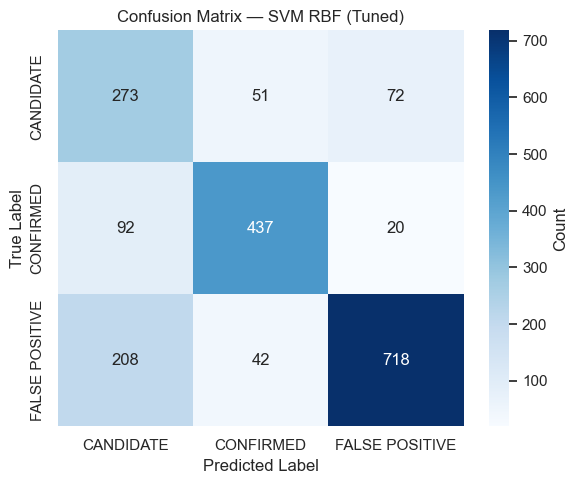

✓ Tuned results stored


In [145]:
print('\n' + '=' * 60)
print('TUNING: SVM RBF (GridSearchCV)')
print('=' * 60)

# Conditional param_grid based on DEBUG_MODE
if DEBUG_MODE:
    svm_param_grid = {
        'model__C': [0.01],
        'model__gamma': ['scale'],
        'model__kernel': ['rbf'],
    }
else:
    svm_param_grid = {
        'model__C': [0.01, 0.1, 1, 3, 10, 30, 100],
        'model__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1, 1],
        'model__kernel': ['rbf'],
    }

svm_search = GridSearchCV(
    estimator=Pipeline(
        build_preprocessing_pipeline(skewed_cols) +
        [('model', SVC(
            kernel='rbf',
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))]
    ),
    param_grid=svm_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()

svm_search.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f'\nTuning time: {elapsed_time:.2f} seconds')

print('\nBest parameters:')
for param, value in svm_search.best_params_.items():
    clean_param = param.replace('model__', '')
    print(f'  - {clean_param}: {value}')

print(f'\nBest CV F1 (macro): {svm_search.best_score_:.4f}')

# Evaluate on test set
y_pred_svm_tuned = svm_search.best_estimator_.predict(X_test)
test_f1_svm_tuned = f1_score(
    y_test,
    y_pred_svm_tuned,
    average='macro',
    zero_division=0
)

# CV vs Test comparison
print(f'Test Set Macro F1: {test_f1_svm_tuned:.4f}')
cv_test_gap = svm_search.best_score_ - test_f1_svm_tuned
print(f'Gap (CV - Test): {cv_test_gap:+.4f}')

if abs(cv_test_gap) > 0.03:
    print(f'⚠️ WARNING: Large gap detected (>{0.03:.2f}) — possible instability or overfitting')

print('\nTest Set Classification Report:')
print_classification_report(y_test, y_pred_svm_tuned, le.classes_)

plot_confusion_matrix(y_test, y_pred_svm_tuned, 'SVM RBF (Tuned)', le.classes_)

tuned_results.append(evaluate_model('SVM RBF (Tuned)', y_test, y_pred_svm_tuned))
print('✓ Tuned results stored')

### 7.6 Stacking Classifier (XGBoost + Random Forest + SVM)


STACKING: XGB + RF + SVM — LogisticRegression final estimator
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Tuning time: 529.37 seconds

Best stacking parameters:
  - final_estimator__C: 1
  - passthrough: False

Best stacking CV F1 (macro): 0.7534
Test Set Macro F1: 0.7461
Gap (CV - Test): +0.0073

Test Set Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.57      0.55      0.56       396
     CONFIRMED       0.84      0.83      0.84       549
FALSE POSITIVE       0.84      0.85      0.84       968

      accuracy                           0.78      1913
     macro avg       0.75      0.74      0.75      1913
  weighted avg       0.78      0.78      0.78      1913



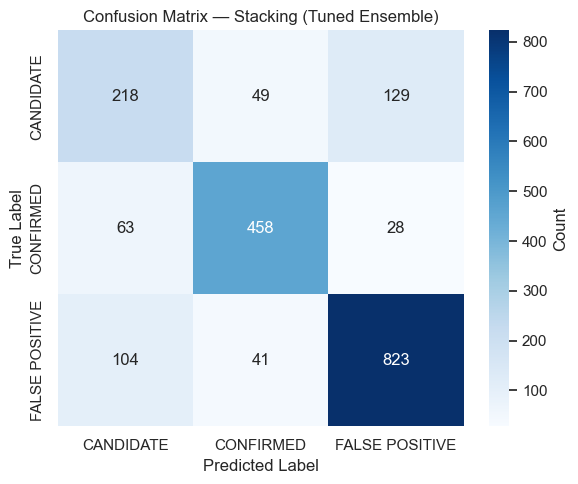

✓ Tuned stacking ensemble results stored


In [146]:
print('\n' + '=' * 60)
print('STACKING: XGB + RF + SVM — LogisticRegression final estimator')
print('=' * 60)

# Ensure base estimators are available from tuning steps
estimators = []

if XGBOOST_AVAILABLE and 'xgb_pipeline' in globals() and xgb_pipeline is not None:
    estimators.append(('xgb', xgb_pipeline))
else:
    print('⚠️ XGBoost tuned estimator not available — skipping XGB in stacking')

if 'rf_search' in globals() and rf_search is not None:
    estimators.append(('rf', rf_search.best_estimator_))
else:
    print('⚠️ RandomForest tuned estimator not available — skipping RF in stacking')

if 'svm_search' in globals() and svm_search is not None:
    estimators.append(('svm', svm_search.best_estimator_))
else:
    print('⚠️ SVM tuned estimator not available — skipping SVM in stacking')

if len(estimators) >= 2:
    base_stack = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=2 if DEBUG_MODE else 5,
        n_jobs=-1
    )

    if DEBUG_MODE:
        stack_param_grid = {
            'passthrough': [False],
            'final_estimator__C': [1]
        }
        stack_cv = 2
    else:
        stack_param_grid = {
            'passthrough': [False, True],
            'final_estimator__C': [1, 10]
        }
        stack_cv = 3

    stack_search = GridSearchCV(
        estimator=base_stack,
        param_grid=stack_param_grid,
        scoring='f1_macro',
        cv=stack_cv,
        n_jobs=-1,
        verbose=1
    )

    start_time = time.time()

    stack_search.fit(X_train, y_train)

    elapsed_time = time.time() - start_time
    print(f'\nTuning time: {elapsed_time:.2f} seconds')

    print('\nBest stacking parameters:')
    for param, value in stack_search.best_params_.items():
        print(f'  - {param}: {value}')

    print(f'\nBest stacking CV F1 (macro): {stack_search.best_score_:.4f}')

    stacking_model = stack_search.best_estimator_
    y_pred_stack = stacking_model.predict(X_test)

    test_f1_stack = f1_score(y_test, y_pred_stack, average='macro', zero_division=0)
    print(f'Test Set Macro F1: {test_f1_stack:.4f}')

    cv_test_gap = stack_search.best_score_ - test_f1_stack
    print(f'Gap (CV - Test): {cv_test_gap:+.4f}')

    if abs(cv_test_gap) > 0.03:
        print(f'⚠️ WARNING: Large gap detected (>{0.03:.2f}) — possible instability or overfitting')

    print('\nTest Set Classification Report:')
    print_classification_report(y_test, y_pred_stack, le.classes_)

    plot_confusion_matrix(y_test, y_pred_stack, 'Stacking (Tuned Ensemble)', le.classes_)

    tuned_results.append(evaluate_model('Stacking (Tuned Ensemble)', y_test, y_pred_stack))

    print('✓ Tuned stacking ensemble results stored')

else:
    print('⚠️ Not enough tuned base estimators available to build stacking model')

## 8. Tuned Model Comparison

In [147]:
# === Build Clean Result Tables Before Final Comparisons ===

baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.drop_duplicates(subset='Model', keep='last')
baseline_df = baseline_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

tuned_df = pd.DataFrame(tuned_results)
tuned_df = tuned_df.drop_duplicates(subset='Model', keep='last')
tuned_df = tuned_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('\n' + '=' * 80)
print('BASELINE MODEL RESULTS')
print('=' * 80)

display(baseline_df.style.format({
    'Accuracy': '{:.4f}',
    'Macro Precision': '{:.4f}',
    'Macro Recall': '{:.4f}',
    'Macro F1': '{:.4f}',
    'Weighted F1': '{:.4f}'
}))

print('\n' + '=' * 80)
print('TUNED MODEL RESULTS')
print('=' * 80)

display(tuned_df.style.format({
    'Accuracy': '{:.4f}',
    'Macro Precision': '{:.4f}',
    'Macro Recall': '{:.4f}',
    'Macro F1': '{:.4f}',
    'Weighted F1': '{:.4f}'
}))

print(f'\nBest baseline model: {baseline_df.iloc[0]["Model"]}')
print(f'Best baseline Macro F1: {baseline_df.iloc[0]["Macro F1"]:.4f}')

print(f'\nBest tuned model: {tuned_df.iloc[0]["Model"]}')
print(f'Best tuned Macro F1: {tuned_df.iloc[0]["Macro F1"]:.4f}')



BASELINE MODEL RESULTS


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,XGBoost (Baseline),0.7742,0.7517,0.7754,0.7565,0.7814
1,Stacking Classifier (Baseline),0.7606,0.7467,0.7655,0.7452,0.7713
2,Random Forest (Baseline),0.7622,0.7343,0.7492,0.7384,0.7683
3,SVM RBF (Baseline),0.7407,0.7324,0.7496,0.7271,0.7533
4,Logistic Regression (Baseline),0.7109,0.7036,0.7275,0.6990,0.7219
5,Decision Tree (Baseline),0.6822,0.6484,0.6460,0.6460,0.6866



TUNED MODEL RESULTS


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,XGBoost (Tuned),0.7815,0.7524,0.7650,0.7560,0.7873
1,Stacking (Tuned Ensemble),0.7836,0.7473,0.7450,0.7461,0.7828
2,Random Forest (Tuned),0.7642,0.7359,0.7481,0.7394,0.7700
3,SVM RBF (Tuned),0.7465,0.7291,0.7424,0.7270,0.7578
4,Decision Tree (Tuned),0.7303,0.7062,0.7269,0.7098,0.7383
5,Logistic Regression (Tuned),0.7099,0.7030,0.7268,0.6982,0.7209



Best baseline model: XGBoost (Baseline)
Best baseline Macro F1: 0.7565

Best tuned model: XGBoost (Tuned)
Best tuned Macro F1: 0.7560


In [148]:
# === Baseline vs Tuned Model Comparison ===

def normalize_model_name(name):
    name = name.replace(' (Baseline)', '')
    name = name.replace(' (Tuned)', '')
    name = name.replace(' (Tuned Ensemble)', '')
    name = name.replace('Stacking Classifier', 'Stacking')
    return name

baseline_clean = baseline_df.copy()
tuned_clean = tuned_df.copy()

baseline_clean = baseline_clean.drop_duplicates(subset='Model', keep='last')
tuned_clean = tuned_clean.drop_duplicates(subset='Model', keep='last')

baseline_clean['Base Model'] = baseline_clean['Model'].apply(normalize_model_name)
tuned_clean['Base Model'] = tuned_clean['Model'].apply(normalize_model_name)

comparison_df = baseline_clean.merge(
    tuned_clean,
    on='Base Model',
    suffixes=(' Baseline', ' Tuned')
)

comparison_df['Macro F1 Improvement'] = (
    comparison_df['Macro F1 Tuned'] - comparison_df['Macro F1 Baseline']
)

comparison_df = comparison_df.sort_values('Macro F1 Tuned', ascending=False).reset_index(drop=True)

print('\n' + '=' * 80)
print('BASELINE VS TUNED MODEL COMPARISON')
print('=' * 80)

display(comparison_df[[
    'Base Model',
    'Macro F1 Baseline',
    'Macro F1 Tuned',
    'Macro F1 Improvement',
    'Accuracy Baseline',
    'Accuracy Tuned',
    'Weighted F1 Baseline',
    'Weighted F1 Tuned'
]].style.format({
    'Macro F1 Baseline': '{:.4f}',
    'Macro F1 Tuned': '{:.4f}',
    'Macro F1 Improvement': '{:+.4f}',
    'Accuracy Baseline': '{:.4f}',
    'Accuracy Tuned': '{:.4f}',
    'Weighted F1 Baseline': '{:.4f}',
    'Weighted F1 Tuned': '{:.4f}'
}))


BASELINE VS TUNED MODEL COMPARISON


,Base Model,Macro F1 Baseline,Macro F1 Tuned,Macro F1 Improvement,Accuracy Baseline,Accuracy Tuned,Weighted F1 Baseline,Weighted F1 Tuned
0,XGBoost,0.7565,0.7560,-0.0005,0.7742,0.7815,0.7814,0.7873
1,Stacking,0.7452,0.7461,+0.0008,0.7606,0.7836,0.7713,0.7828
2,Random Forest,0.7384,0.7394,+0.0010,0.7622,0.7642,0.7683,0.7700
3,SVM RBF,0.7271,0.7270,-0.0001,0.7407,0.7465,0.7533,0.7578
4,Decision Tree,0.6460,0.7098,+0.0638,0.6822,0.7303,0.6866,0.7383
5,Logistic Regression,0.6990,0.6982,-0.0008,0.7109,0.7099,0.7219,0.7209


### 8.1 Baseline vs Tuned Comparison

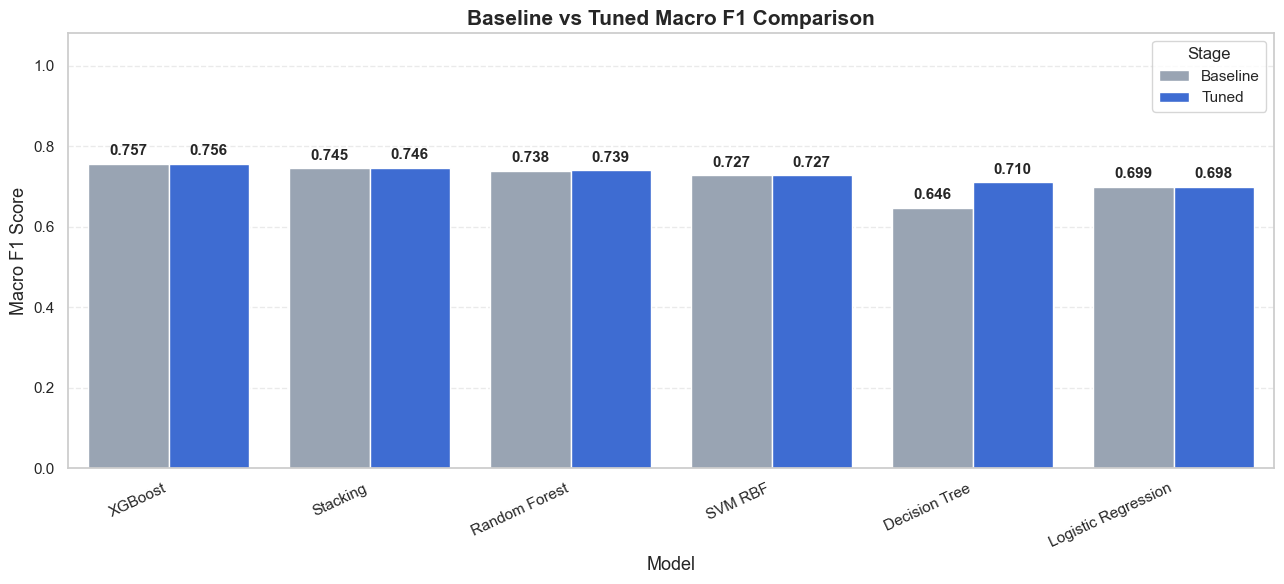

In [149]:
# === Plot 1: Baseline vs Tuned Macro F1 ===

plot_df = comparison_df[['Base Model', 'Macro F1 Baseline', 'Macro F1 Tuned']].melt(
    id_vars='Base Model',
    var_name='Stage',
    value_name='Macro F1'
)

plot_df['Stage'] = plot_df['Stage'].replace({
    'Macro F1 Baseline': 'Baseline',
    'Macro F1 Tuned': 'Tuned'
})

plt.figure(figsize=(13, 6))

ax = sns.barplot(
    data=plot_df,
    x='Base Model',
    y='Macro F1',
    hue='Stage',
    palette=STAGE_PALETTE
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=4,
        fontsize=11,
        fontweight='bold'
    )

plt.title('Baseline vs Tuned Macro F1 Comparison', fontsize=15, fontweight='bold')
plt.xlabel('Model', fontsize=13)
plt.ylabel('Macro F1 Score', fontsize=13)
plt.ylim(0, 1.08)
plt.xticks(rotation=25, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title='Stage', title_fontsize=12, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

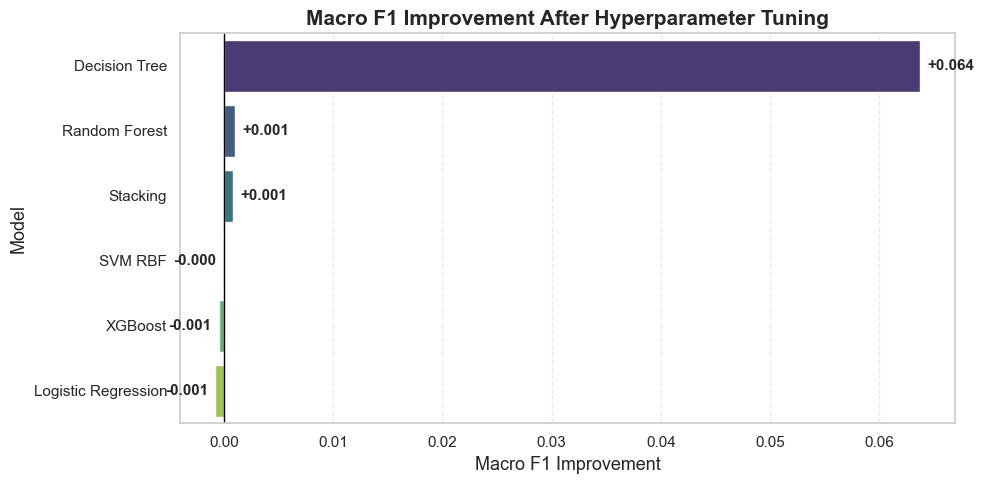

In [150]:
# === Plot 2: Macro F1 Improvement After Tuning ===

improvement_df = comparison_df.sort_values('Macro F1 Improvement', ascending=False)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=improvement_df,
    x='Macro F1 Improvement',
    y='Base Model',
    hue='Base Model',
    palette='viridis',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%+.3f',
        padding=5,
        fontsize=11,
        fontweight='bold'
    )

plt.axvline(0, color='black', linewidth=1)
plt.title('Macro F1 Improvement After Hyperparameter Tuning', fontsize=15, fontweight='bold')
plt.xlabel('Macro F1 Improvement', fontsize=13)
plt.ylabel('Model', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 8.2 Model Stability: CV vs Test Macro F1

,Model,CV Macro F1,Test Macro F1,Gap (CV - Test)
0,XGBoost,0.7670,0.7560,+0.0110
1,Stacking,0.7534,0.7461,+0.0073
2,Random Forest,0.7553,0.7394,+0.0159
3,SVM RBF,0.7369,0.7270,+0.0098
4,Decision Tree,0.7137,0.7098,+0.0039
5,Logistic Regression,0.6867,0.6982,-0.0115


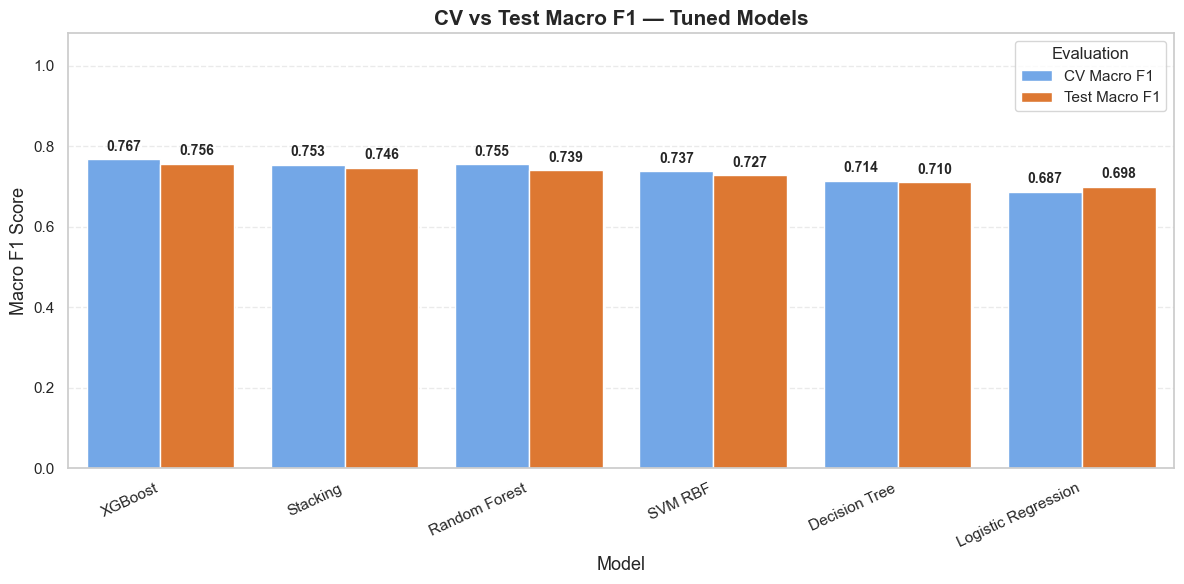

In [151]:
# === 8.2 Model Stability: CV vs Test Macro F1 ===

cv_score_rows = []

search_objects = {
    'Logistic Regression': lr_search,
    'Decision Tree': dt_search,
    'Random Forest': rf_search,
    'SVM RBF': svm_search,
}

if 'xgb_search' in globals() and xgb_search is not None:
    search_objects['XGBoost'] = xgb_search

if 'stack_search' in globals() and stack_search is not None:
    search_objects['Stacking'] = stack_search

for model_name, search_obj in search_objects.items():
    tuned_row = comparison_df[comparison_df['Base Model'] == model_name]
    
    if len(tuned_row) > 0:
        cv_f1 = search_obj.best_score_
        test_f1 = tuned_row.iloc[0]['Macro F1 Tuned']
        gap = cv_f1 - test_f1
        
        cv_score_rows.append({
            'Model': model_name,
            'CV Macro F1': cv_f1,
            'Test Macro F1': test_f1,
            'Gap (CV - Test)': gap
        })

cv_test_df = pd.DataFrame(cv_score_rows)
cv_test_df = cv_test_df.sort_values('Test Macro F1', ascending=False).reset_index(drop=True)

display(cv_test_df.style.format({
    'CV Macro F1': '{:.4f}',
    'Test Macro F1': '{:.4f}',
    'Gap (CV - Test)': '{:+.4f}'
}))

cv_plot_df = cv_test_df[['Model', 'CV Macro F1', 'Test Macro F1']].melt(
    id_vars='Model',
    var_name='Evaluation',
    value_name='Macro F1'
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=cv_plot_df,
    x='Model',
    y='Macro F1',
    hue='Evaluation',
    palette={
        'CV Macro F1': '#60A5FA',
        'Test Macro F1': '#F97316'
    }
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=4,
        fontsize=10,
        fontweight='bold'
    )

plt.title('CV vs Test Macro F1 — Tuned Models', fontsize=15, fontweight='bold')
plt.xlabel('Model', fontsize=13)
plt.ylabel('Macro F1 Score', fontsize=13)
plt.ylim(0, 1.08)
plt.xticks(rotation=25, ha='right', fontsize=11)
plt.legend(title='Evaluation')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 8.3 Class-wise F1 Improvement

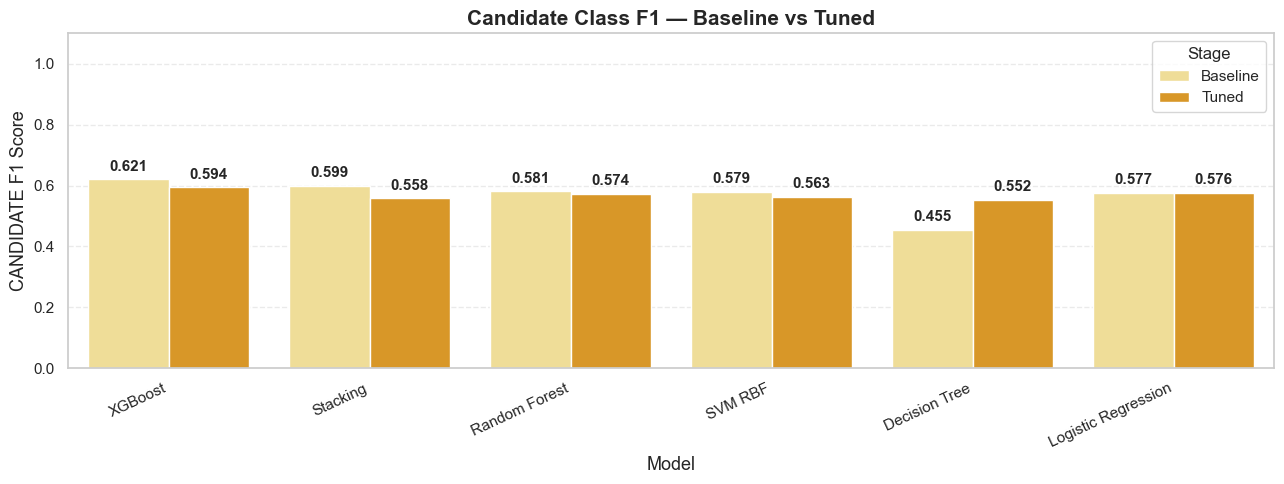

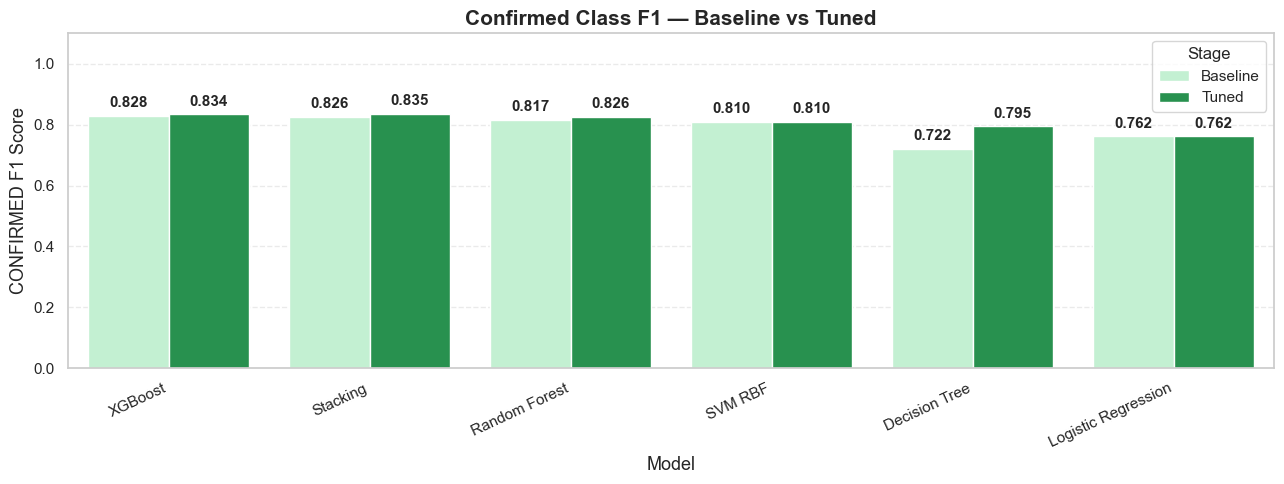

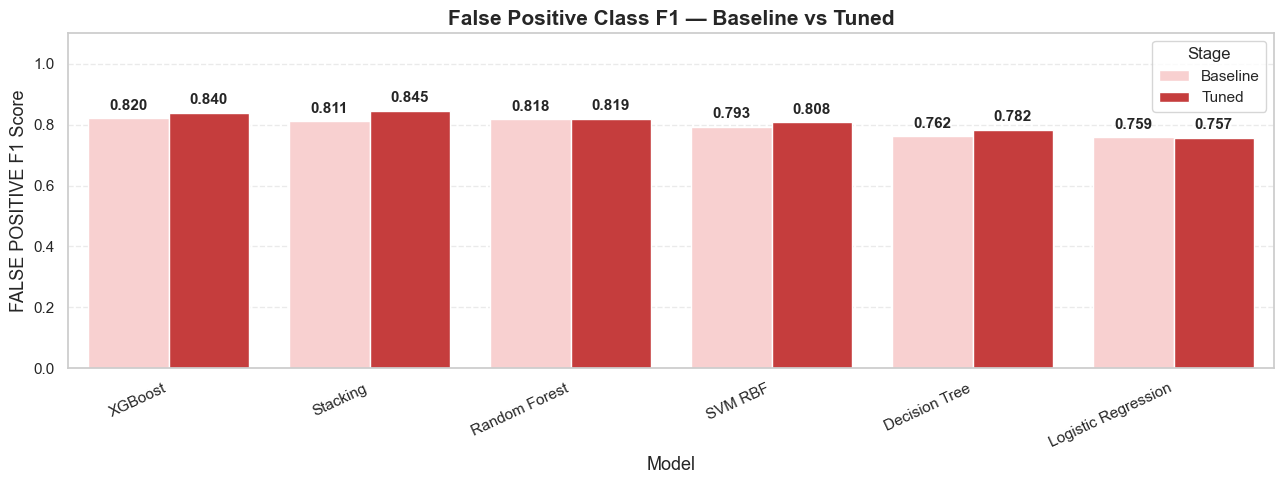

In [152]:
# === 8.3 Class-wise F1 — Baseline vs Tuned ===

baseline_predictions = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'SVM RBF': y_pred_svm
}

tuned_predictions = {
    'Logistic Regression': y_pred_lr_tuned,
    'Decision Tree': y_pred_dt_tuned,
    'Random Forest': y_pred_rf_tuned,
    'SVM RBF': y_pred_svm_tuned
}

if XGBOOST_AVAILABLE and 'y_pred_xgb' in globals() and 'y_pred_xgb_tuned' in globals():
    baseline_predictions['XGBoost'] = y_pred_xgb
    tuned_predictions['XGBoost'] = y_pred_xgb_tuned

if 'y_pred_stack_baseline' in globals() and 'y_pred_stack' in globals():
    baseline_predictions['Stacking'] = y_pred_stack_baseline
    tuned_predictions['Stacking'] = y_pred_stack

class_f1_rows = []

for model_name in baseline_predictions.keys():
    if model_name in tuned_predictions:
        baseline_f1_per_class = f1_score(
            y_test,
            baseline_predictions[model_name],
            average=None,
            labels=np.arange(len(le.classes_)),
            zero_division=0
        )

        tuned_f1_per_class = f1_score(
            y_test,
            tuned_predictions[model_name],
            average=None,
            labels=np.arange(len(le.classes_)),
            zero_division=0
        )

        for class_name, baseline_f1, tuned_f1 in zip(
            CLASS_ORDER,
            baseline_f1_per_class,
            tuned_f1_per_class
        ):
            class_f1_rows.append({
                'Model': model_name,
                'Class': class_name,
                'Baseline F1': baseline_f1,
                'Tuned F1': tuned_f1,
                'F1 Improvement': tuned_f1 - baseline_f1
            })

class_f1_compare_df = pd.DataFrame(class_f1_rows)

# Same model order for all class plots, based on overall tuned Macro F1
model_order = (
    comparison_df
    .sort_values('Macro F1 Tuned', ascending=False)['Base Model']
    .tolist()
)

# Keep only models available in class_f1_compare_df
model_order = [
    model for model in model_order
    if model in class_f1_compare_df['Model'].unique()
]

class_titles = {
    'CANDIDATE': 'Candidate Class F1 — Baseline vs Tuned',
    'CONFIRMED': 'Confirmed Class F1 — Baseline vs Tuned',
    'FALSE POSITIVE': 'False Positive Class F1 — Baseline vs Tuned'
}

for class_name in CLASS_ORDER:
    class_df = class_f1_compare_df[class_f1_compare_df['Class'] == class_name].copy()

    plot_df = class_df[['Model', 'Baseline F1', 'Tuned F1']].melt(
        id_vars='Model',
        var_name='Stage',
        value_name='F1 Score'
    )

    plot_df['Stage'] = plot_df['Stage'].replace({
        'Baseline F1': 'Baseline',
        'Tuned F1': 'Tuned'
    })

    plt.figure(figsize=(13, 5))

    ax = sns.barplot(
        data=plot_df,
        x='Model',
        y='F1 Score',
        hue='Stage',
        order=model_order,
        palette=class_stage_palettes[class_name]
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.3f',
            padding=4,
            fontsize=11,
            fontweight='bold'
        )

    plt.title(
        class_titles.get(class_name, f'{class_name} Class F1 — Baseline vs Tuned'),
        fontsize=15,
        fontweight='bold'
    )
    plt.xlabel('Model', fontsize=13)
    plt.ylabel(f'{class_name} F1 Score', fontsize=13)
    plt.ylim(0, 1.10)
    plt.xticks(rotation=25, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    plt.legend(title='Stage', title_fontsize=12, fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

## 9. Final Model Selection

### 9.1 Final Model Selection

In [153]:
# Select the best tuned estimator dynamically and reuse it everywhere downstream
estimator_lookup = {}

if 'lr_search' in globals() and lr_search is not None:
    estimator_lookup['Logistic Regression (Tuned)'] = lr_search.best_estimator_
if 'dt_search' in globals() and dt_search is not None:
    estimator_lookup['Decision Tree (Tuned)'] = dt_search.best_estimator_
if 'rf_search' in globals() and rf_search is not None:
    estimator_lookup['Random Forest (Tuned)'] = rf_search.best_estimator_
if XGBOOST_AVAILABLE and 'xgb_search' in globals() and xgb_search is not None:
    estimator_lookup['XGBoost (Tuned)'] = xgb_search.best_estimator_
if 'svm_search' in globals() and svm_search is not None:
    estimator_lookup['SVM RBF (Tuned)'] = svm_search.best_estimator_
if 'stacking_model' in globals() and stacking_model is not None:
    estimator_lookup['Stacking (Tuned Ensemble)'] = stacking_model

if tuned_df.empty:
    raise ValueError('No tuned models available. Run tuning cells first.')

final_model_row = tuned_df.sort_values('Macro F1', ascending=False).iloc[0]
final_model_name = final_model_row['Model']
final_f1 = final_model_row['Macro F1']

if final_model_name not in estimator_lookup:
    raise ValueError(f'Best tuned estimator not found for {final_model_name}.')

final_estimator = estimator_lookup[final_model_name]

# Single-source final predictions/scores used by all final analyses
final_y_pred = final_estimator.predict(X_test)

if hasattr(final_estimator, 'predict_proba'):
    final_y_score = final_estimator.predict_proba(X_test)
elif hasattr(final_estimator, 'decision_function'):
    final_y_score = final_estimator.decision_function(X_test)
    if final_y_score.ndim == 1:
        final_y_score = np.vstack([1 - final_y_score, final_y_score]).T
else:
    final_y_score = None

print('\n' + '=' * 80)
print('FINAL MODEL SELECTION')
print('=' * 80)

print(f'\nSelected Model: {final_model_name}')
print(f'Macro F1 (main metric): {final_f1:.4f}')
print(f'Accuracy: {final_model_row["Accuracy"]:.4f}')
print(f'Macro Precision: {final_model_row["Macro Precision"]:.4f}')
print(f'Macro Recall: {final_model_row["Macro Recall"]:.4f}')
print(f'Weighted F1: {final_model_row["Weighted F1"]:.4f}')

print(f'\nTraining Time Analysis:')
if final_model_name == 'XGBoost (Tuned)' and XGBOOST_AVAILABLE and 'xgb_search' in globals() and xgb_search is not None:
    print('  - Final estimator refit on full training split using Optuna-selected hyperparameters')
    print(f'  - Optuna best CV F1 (macro): {xgb_search.best_score_:.4f}')
else:
    print('  - Final estimator reused from the tuned model comparison stage')

print(f'\n✓ Final {final_model_name} model selected and ready for detailed analysis')


FINAL MODEL SELECTION

Selected Model: XGBoost (Tuned)
Macro F1 (main metric): 0.7560
Accuracy: 0.7815
Macro Precision: 0.7524
Macro Recall: 0.7650
Weighted F1: 0.7873

Training Time Analysis:
  - Final estimator refit on full training split using Optuna-selected hyperparameters
  - Optuna best CV F1 (macro): 0.7670

✓ Final XGBoost (Tuned) model selected and ready for detailed analysis


## 10. Final Model Analysis

### 10.1 Final Classification Report

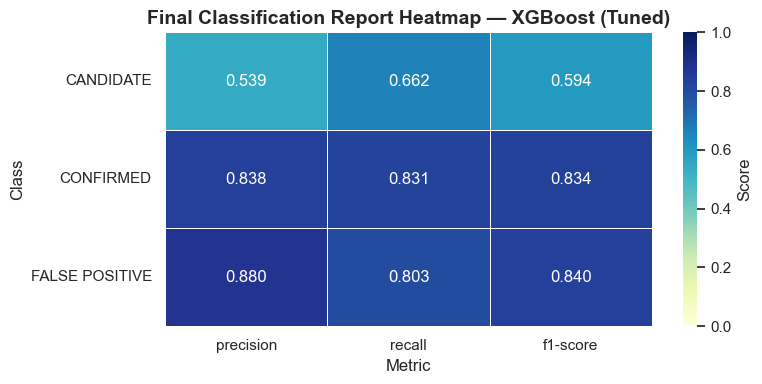

In [154]:
# === 10.1 Final Classification Report Heatmap ===

report_dict = classification_report(
    y_test,
    final_y_pred,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

# Keep only class rows and main metrics
class_report_df = report_df.loc[CLASS_ORDER, ['precision', 'recall', 'f1-score']]

plt.figure(figsize=(8, 4))

sns.heatmap(
    class_report_df,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Score'}
)

plt.title(f'Final Classification Report Heatmap — {final_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Metric')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

### 10.2 Final Confusion Matrix

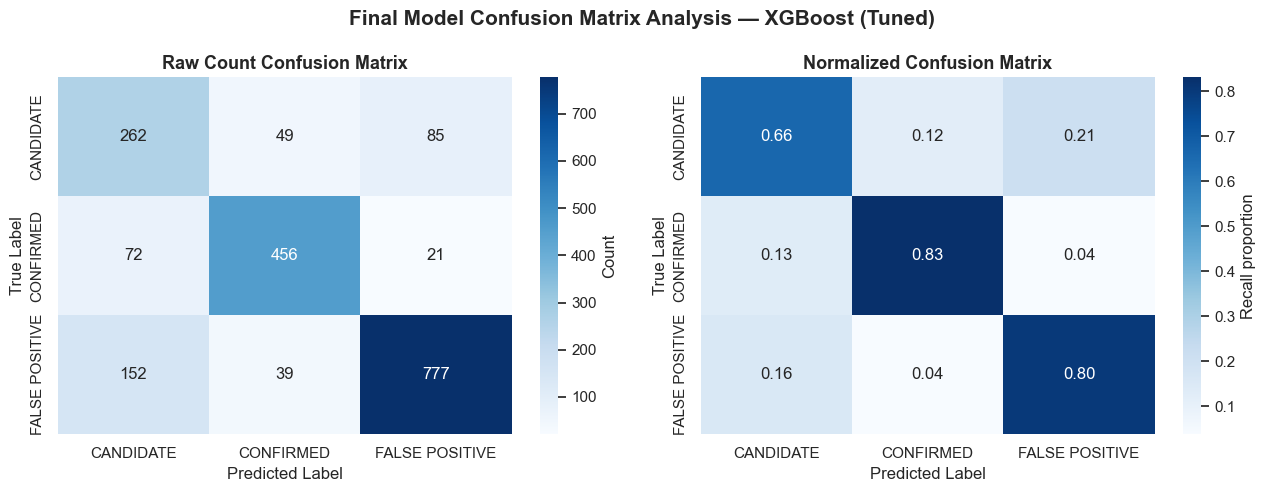

In [155]:
# === 10.2 Dual Confusion Matrix: Raw Count and Normalized ===

cm = confusion_matrix(y_test, final_y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=axes[0],
    cbar_kws={'label': 'Count'}
)

axes[0].set_title('Raw Count Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=axes[1],
    cbar_kws={'label': 'Recall proportion'}
)

axes[1].set_title('Normalized Confusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.suptitle(f'Final Model Confusion Matrix Analysis — {final_model_name}', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.4 Model Discriminative Ability (ROC & PR Curves)

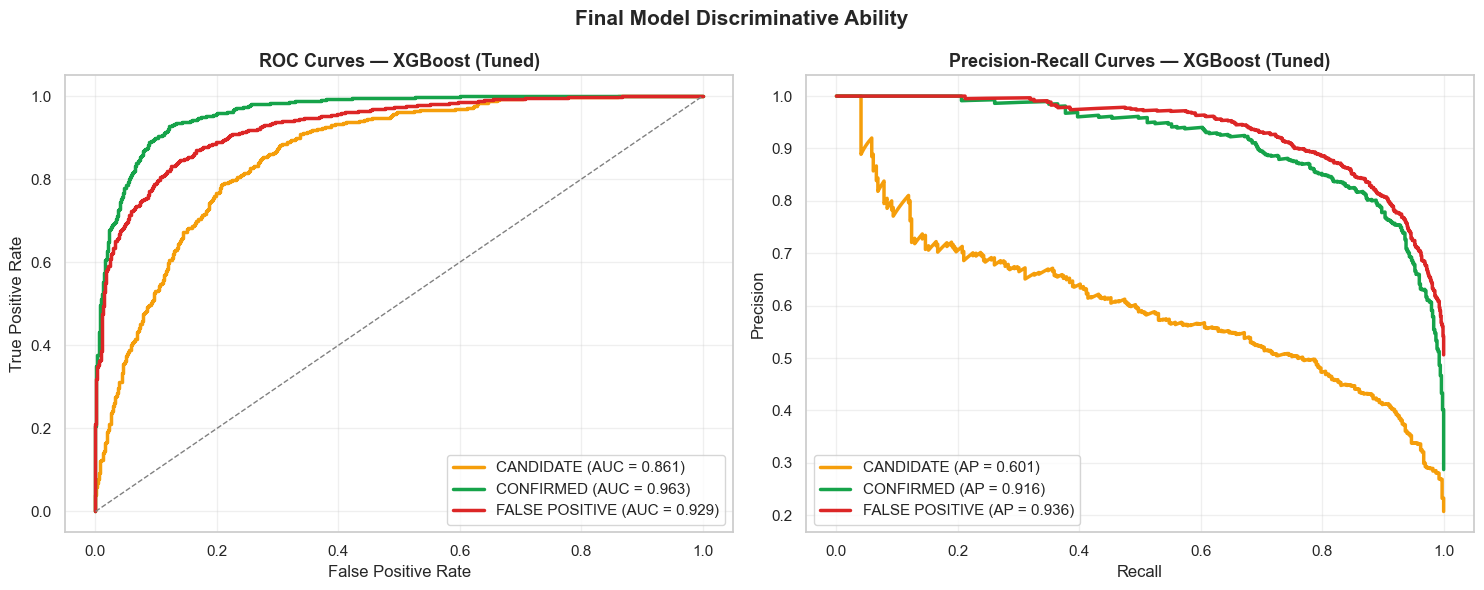

In [156]:
# === 10.4 Model Discriminative Ability (ROC & PR Curves) ===

if final_y_score is not None:
    y_test_bin = label_binarize(y_test, classes=np.arange(len(CLASS_ORDER)))

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # ROC Curves
    for i, class_name in enumerate(CLASS_ORDER):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], final_y_score[:, i])
        roc_auc = auc(fpr, tpr)

        axes[0].plot(
            fpr,
            tpr,
            linewidth=2.5,
            color=CLASS_PALETTE[class_name],
            label=f'{class_name} (AUC = {roc_auc:.3f})'
        )

    axes[0].plot([0, 1], [0, 1], linestyle='--', linewidth=1, color='gray')
    axes[0].set_title(f'ROC Curves — {final_model_name}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Precision-Recall Curves
    for i, class_name in enumerate(CLASS_ORDER):
        precision, recall, _ = precision_recall_curve(
            y_test_bin[:, i],
            final_y_score[:, i]
        )
        avg_precision = average_precision_score(
            y_test_bin[:, i],
            final_y_score[:, i]
        )

        axes[1].plot(
            recall,
            precision,
            linewidth=2.5,
            color=CLASS_PALETTE[class_name],
            label=f'{class_name} (AP = {avg_precision:.3f})'
        )

    axes[1].set_title(f'Precision-Recall Curves — {final_model_name}', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle('Final Model Discriminative Ability', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print(f'ROC and Precision-Recall curves are not available for {final_model_name}.')
    print('The final estimator does not provide predict_proba or decision_function outputs.')

### 10.5 Confidence Calibration Plot

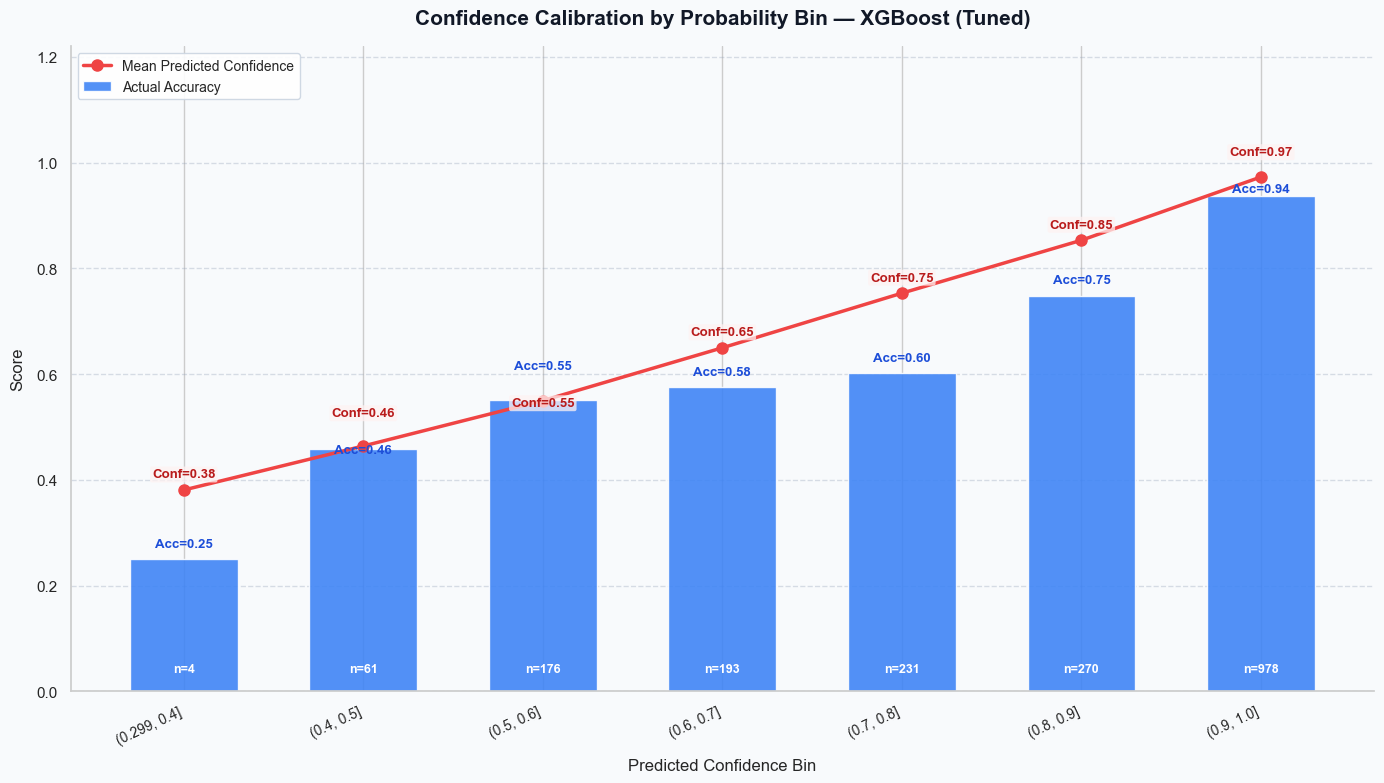

In [157]:
# === 10.x Confidence Calibration Plot — Dinamik Etiket Konumlandırma ===

if final_y_score is not None:
    final_confidence = np.max(final_y_score, axis=1)
    correct_predictions = (final_y_pred == y_test)

    confidence_bin_df = pd.DataFrame({
        'Confidence': final_confidence,
        'Correct': correct_predictions.astype(int)
    })

    bins = np.arange(0.3, 1.01, 0.1)
    confidence_bin_df['Confidence Bin'] = pd.cut(
        confidence_bin_df['Confidence'],
        bins=bins,
        include_lowest=True
    )

    calibration_table = confidence_bin_df.groupby(
        'Confidence Bin', observed=True
    ).agg(
        Count=('Correct', 'count'),
        Accuracy=('Correct', 'mean'),
        Mean_Confidence=('Confidence', 'mean')
    ).reset_index()

    calibration_table['Confidence Bin Label'] = calibration_table['Confidence Bin'].astype(str)

    fig, ax = plt.subplots(figsize=(14, 8))
    fig.patch.set_facecolor('#F8FAFC')
    ax.set_facecolor('#F8FAFC')

    x = np.arange(len(calibration_table))

    # --- Barlar ---
    ax.bar(
        x,
        calibration_table['Accuracy'],
        width=0.6,
        color='#3B82F6',
        alpha=0.88,
        label='Actual Accuracy',
        zorder=2
    )

    # --- Kırmızı çizgi ---
    ax.plot(
        x,
        calibration_table['Mean_Confidence'],
        color='#EF4444',
        marker='o',
        linewidth=2.5,
        markersize=8,
        label='Mean Predicted Confidence',
        zorder=3
    )

    MIN_GAP = 0.07   # iki etiket arasında garanti edilecek minimum mesafe
    OFFSET  = 0.018  # her etiketin kendi referans noktasından yukarı boşluğu

    for i, row in calibration_table.iterrows():
        accuracy  = row['Accuracy']
        mean_conf = row['Mean_Confidence']
        count     = int(row['Count'])

        # Hangisi daha yüksekte?
        top_val    = max(accuracy, mean_conf)
        bottom_val = min(accuracy, mean_conf)

        top_y    = top_val    + OFFSET
        bottom_y = bottom_val + OFFSET

        # Çakışıyorsa alt etiketi aşağı, üst etiketi yukarı it
        if top_y - bottom_y < MIN_GAP:
            mid = (top_y + bottom_y) / 2
            top_y    = mid + MIN_GAP / 2
            bottom_y = mid - MIN_GAP / 2

        # Hangi değer hangisi?
        if accuracy >= mean_conf:
            acc_y, conf_y = top_y, bottom_y
        else:
            acc_y, conf_y = bottom_y, top_y

        # Accuracy etiketi
        ax.text(
            i, acc_y,
            f'Acc={accuracy:.2f}',
            ha='center', va='bottom',
            fontsize=9.5, fontweight='bold',
            color='#1D4ED8', zorder=4
        )

        # Conf etiketi
        ax.text(
            i, conf_y,
            f'Conf={mean_conf:.2f}',
            ha='center', va='bottom',
            fontsize=9.5, fontweight='bold',
            color='#B91C1C', zorder=4,
            bbox=dict(boxstyle='round,pad=0.15', fc='#FEF2F2', ec='none', alpha=0.75)
        )

        # n= etiketi — barın içinde
        ax.text(
            i, 0.03,
            f'n={count}',
            ha='center', va='bottom',
            fontsize=9, color='white',
            fontweight='bold', zorder=4
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        calibration_table['Confidence Bin Label'],
        rotation=25, ha='right', fontsize=10
    )
    ax.set_ylim(0, 1.22)
    ax.set_title(
        f'Confidence Calibration by Probability Bin — {final_model_name}',
        fontsize=15, fontweight='bold', pad=16, color='#111827'
    )
    ax.set_xlabel('Predicted Confidence Bin', fontsize=12, labelpad=8)
    ax.set_ylabel('Score', fontsize=12, labelpad=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}'))
    ax.grid(axis='y', linestyle='--', alpha=0.35, color='#94A3B8', zorder=1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=10, framealpha=0.9, edgecolor='#CBD5E1', loc='upper left')

    plt.tight_layout()
    plt.show()

else:
    print('Confidence calibration plot is not available because final_y_score is None.')

## 11 SHAP Analysis

In [158]:
# === 11.1 SHAP Setup ===

print('\n' + '=' * 80)
print('SHAP SETUP')
print('=' * 80)

print(f'Final model: {final_model_name}')
print(f'SHAP available: {SHAP_AVAILABLE}')

# Extract the actual model from the pipeline
final_model = (
    final_estimator.named_steps['model']
    if hasattr(final_estimator, 'named_steps') and 'model' in final_estimator.named_steps
    else final_estimator
)

# Prepare preprocessed test data for SHAP
# Important: SMOTE is skipped because it is a sampler, not a transformer.
if hasattr(final_estimator, 'named_steps'):
    X_test_shap_temp = X_test.copy()
    feature_names_shap = X_test.columns.tolist()

    for step_name, step in final_estimator.named_steps.items():
        if step_name == 'model':
            break

        if step_name == 'smote':
            print('  → Skipping SMOTE for SHAP data preparation')
            continue

        if hasattr(step, 'transform'):
            X_test_shap_temp = step.transform(X_test_shap_temp)

            if isinstance(X_test_shap_temp, pd.DataFrame):
                feature_names_shap = X_test_shap_temp.columns.tolist()
            else:
                X_test_shap_temp = pd.DataFrame(
                    X_test_shap_temp,
                    columns=feature_names_shap,
                    index=X_test.index
                )
        else:
            print(f'  → Skipping {step_name}: no transform method')

    X_test_shap_df = X_test_shap_temp.copy()

else:
    X_test_shap_df = X_test.copy()
    feature_names_shap = X_test.columns.tolist()

# Use a sample for faster SHAP analysis
shap_sample_size = min(500, X_test_shap_df.shape[0])

X_test_shap_sample = X_test_shap_df.sample(
    n=shap_sample_size,
    random_state=RANDOM_STATE
)

print(f'\nSHAP sample size: {shap_sample_size}')
print(f'Number of features: {len(feature_names_shap)}')

if not SHAP_AVAILABLE:
    print('\n⚠️ SHAP is not available. Install it with: pip install shap')

elif hasattr(final_model, 'feature_importances_'):
    print('\n✓ Final model is tree-based and suitable for SHAP TreeExplainer.')
    print('✓ SHAP input data prepared successfully.')

else:
    print('\n⚠️ Final model may not support direct TreeExplainer SHAP analysis.')
    print('   SHAP is most straightforward for tree-based models such as XGBoost, Random Forest, and Decision Tree.')


SHAP SETUP
Final model: XGBoost (Tuned)
SHAP available: True
  → Skipping SMOTE for SHAP data preparation

SHAP sample size: 500
Number of features: 19

✓ Final model is tree-based and suitable for SHAP TreeExplainer.
✓ SHAP input data prepared successfully.


### 11.2 SHAP Global Feature Importance

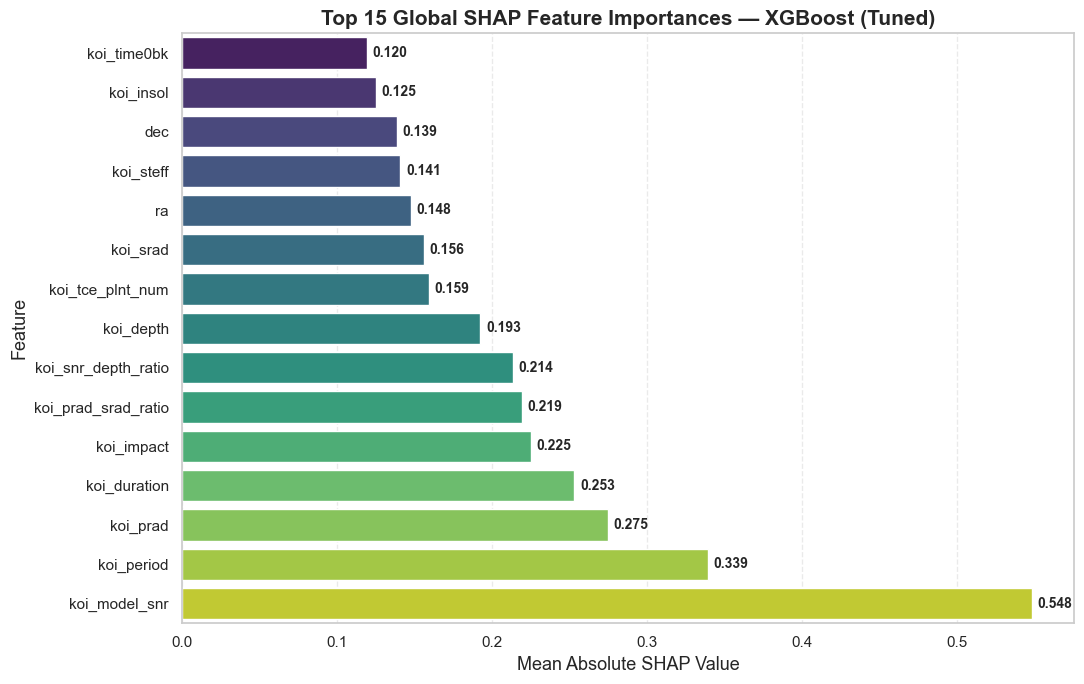

✓ SHAP global feature importance completed.
  → Higher mean absolute SHAP value means stronger overall impact on model predictions.


In [159]:
# === 11.2 SHAP Global Feature Importance ===

if SHAP_AVAILABLE and hasattr(final_model, 'feature_importances_'):

    # Create SHAP explainer for the final tree-based model
    explainer = shap.TreeExplainer(final_model)

    # Compute SHAP values on the prepared test sample
    shap_values = explainer.shap_values(X_test_shap_sample)

    # Handle multiclass SHAP output
    # XGBoost multiclass may return either:
    # 1) list of arrays: [class_0_values, class_1_values, class_2_values]
    # 2) array with shape: (samples, features, classes)
    if isinstance(shap_values, list):
        mean_abs_shap = np.mean(
            [np.abs(class_values).mean(axis=0) for class_values in shap_values],
            axis=0
        )

    elif len(np.array(shap_values).shape) == 3:
        mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

    else:
        mean_abs_shap = np.abs(shap_values).mean(axis=0)

    shap_importance_df = pd.DataFrame({
        'Feature': X_test_shap_sample.columns,
        'Mean |SHAP value|': mean_abs_shap
    }).sort_values('Mean |SHAP value|', ascending=False)

    top_shap_features = shap_importance_df.head(15).sort_values(
        'Mean |SHAP value|',
        ascending=True
    )

    plt.figure(figsize=(11, 7))

    ax = sns.barplot(
        data=top_shap_features,
        x='Mean |SHAP value|',
        y='Feature',
        hue='Feature',
        palette='viridis',
        legend=False
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.3f',
            padding=4,
            fontsize=10,
            fontweight='bold'
        )

    plt.title(
        f'Top 15 Global SHAP Feature Importances — {final_model_name}',
        fontsize=15,
        fontweight='bold'
    )
    plt.xlabel('Mean Absolute SHAP Value', fontsize=13)
    plt.ylabel('Feature', fontsize=13)
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    print('✓ SHAP global feature importance completed.')
    print('  → Higher mean absolute SHAP value means stronger overall impact on model predictions.')

else:
    print(f'SHAP global feature importance is not available for {final_model_name}.')
    print('This section requires SHAP and a tree-based final model.')

### 11.3 SHAP Summary / Beeswarm Plot

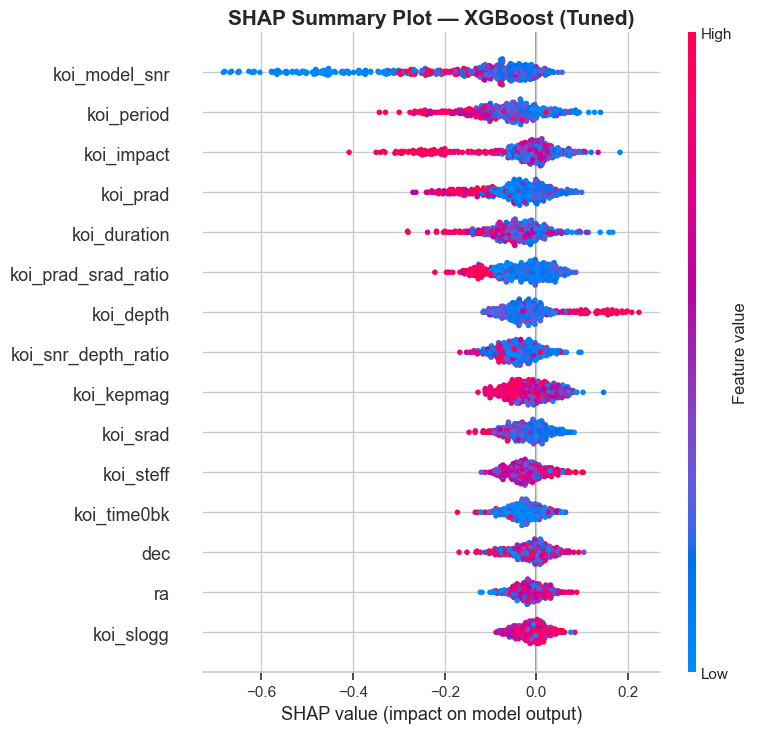

In [160]:
# === 11.3 SHAP Summary / Beeswarm Plot ===

if SHAP_AVAILABLE and 'shap_values' in globals():

    shap_array = np.array(shap_values)

    # Multiclass SHAP handling
    if isinstance(shap_values, list):
        # list: [class_0, class_1, class_2], each shape = samples x features
        shap_values_for_summary = np.mean(np.array(shap_values), axis=0)

    elif shap_array.ndim == 3:
        # array: samples x features x classes
        shap_values_for_summary = np.mean(shap_array, axis=2)

    else:
        shap_values_for_summary = shap_array

    shap.summary_plot(
        shap_values_for_summary,
        X_test_shap_sample,
        feature_names=X_test_shap_sample.columns,
        max_display=15,
        show=False
    )

    plt.title(
        f'SHAP Summary Plot — {final_model_name}',
        fontsize=15,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

else:
    print('SHAP summary plot is not available.')
    print('Run SHAP global feature importance first.')

### 11.4 Class-wise SHAP Feature Importance

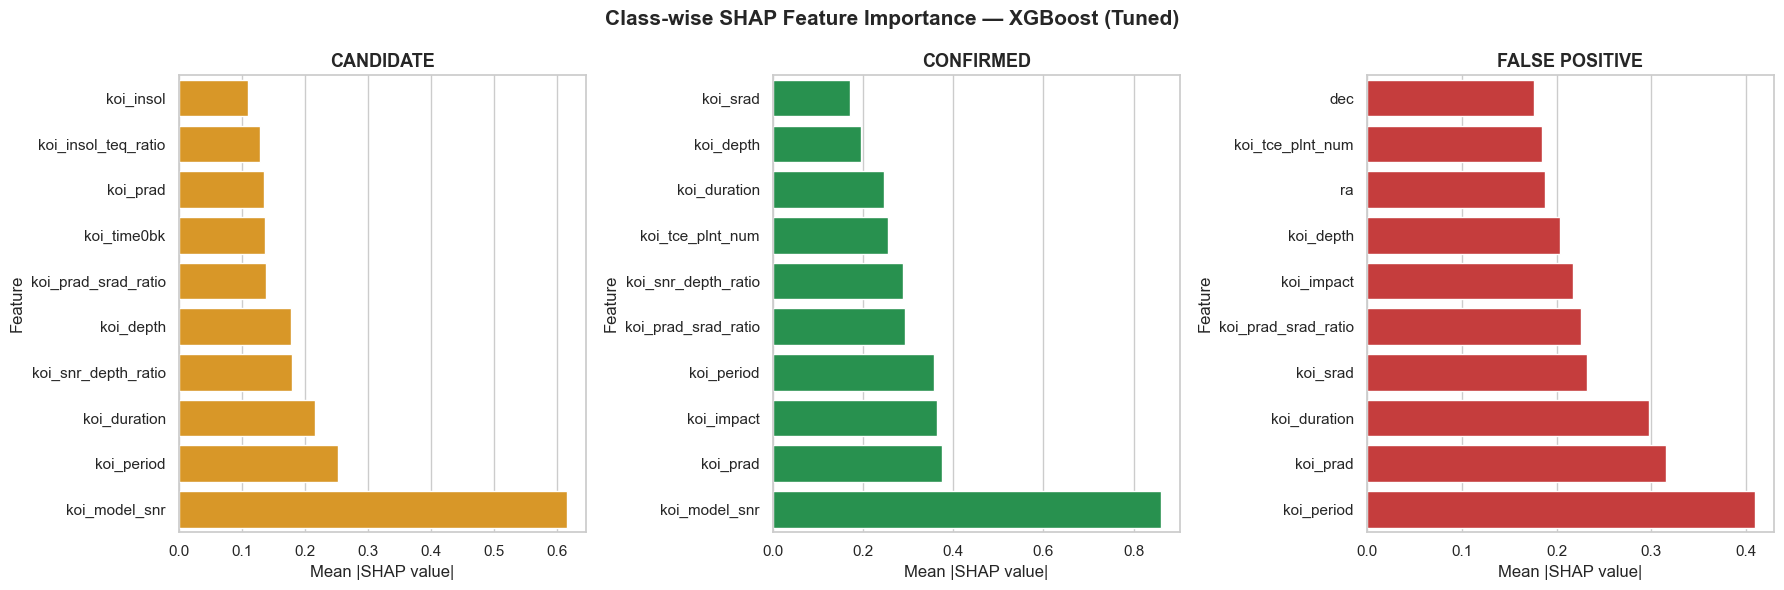

In [161]:
# === 11.4 Class-wise SHAP Feature Importance ===

if SHAP_AVAILABLE and 'shap_values' in globals():

    shap_array = np.array(shap_values)

    class_importance_rows = []

    if isinstance(shap_values, list):
        # SHAP output as list of class arrays
        for class_idx, class_name in enumerate(CLASS_ORDER):
            mean_abs = np.abs(shap_values[class_idx]).mean(axis=0)

            for feature, value in zip(X_test_shap_sample.columns, mean_abs):
                class_importance_rows.append({
                    'Class': class_name,
                    'Feature': feature,
                    'Mean |SHAP value|': value
                })

    elif shap_array.ndim == 3:
        # Usually shape: samples x features x classes
        for class_idx, class_name in enumerate(CLASS_ORDER):
            mean_abs = np.abs(shap_array[:, :, class_idx]).mean(axis=0)

            for feature, value in zip(X_test_shap_sample.columns, mean_abs):
                class_importance_rows.append({
                    'Class': class_name,
                    'Feature': feature,
                    'Mean |SHAP value|': value
                })

    else:
        print('Class-wise SHAP is not available because SHAP output is not multiclass.')

    if class_importance_rows:
        class_shap_df = pd.DataFrame(class_importance_rows)

        fig, axes = plt.subplots(1, len(CLASS_ORDER), figsize=(18, 6), sharex=False)

        for ax, class_name in zip(axes, CLASS_ORDER):
            top_class_features = (
                class_shap_df[class_shap_df['Class'] == class_name]
                .sort_values('Mean |SHAP value|', ascending=False)
                .head(10)
                .sort_values('Mean |SHAP value|', ascending=True)
            )

            sns.barplot(
                data=top_class_features,
                x='Mean |SHAP value|',
                y='Feature',
                ax=ax,
                color=CLASS_PALETTE[class_name]
            )

            ax.set_title(f'{class_name}', fontsize=13, fontweight='bold')
            ax.set_xlabel('Mean |SHAP value|')
            ax.set_ylabel('Feature')

        plt.suptitle(
            f'Class-wise SHAP Feature Importance — {final_model_name}',
            fontsize=15,
            fontweight='bold'
        )
        plt.tight_layout()
        plt.show()

else:
    print('Class-wise SHAP feature importance is not available.')

### Summary

In [162]:
print('\n' + '=' * 80)
print('MACHINE LEARNING WORKFLOW — FINAL SUMMARY')
print('=' * 80)

# Clean result tables
baseline_summary_df = baseline_df.drop_duplicates(subset='Model', keep='last').copy()
tuned_summary_df = tuned_df.drop_duplicates(subset='Model', keep='last').copy()

best_baseline_model = baseline_summary_df.iloc[0]['Model']
best_baseline_f1 = baseline_summary_df.iloc[0]['Macro F1']

best_tuned_model = tuned_summary_df.iloc[0]['Model']
best_tuned_f1 = tuned_summary_df.iloc[0]['Macro F1']

print('\n1. DATASET')
print(f'   - Total samples: {len(df)}')
print(f'   - Final numeric features: {len(numeric_cols)}')
print(f'   - Target classes: {len(le.classes_)}')
print(f'   - Class labels: {", ".join(le.classes_)}')
print('   - Class distribution: Moderately imbalanced')

print('\n2. FEATURE SELECTION AND PREPROCESSING')
print(f'   - Leakage columns removed: {len(leakage_cols)}')
print(f'   - Metadata columns removed: {len(id_meta_cols)}')
print(f'   - Engineered ratio features added: {len(new_cols) if "new_cols" in globals() else "N/A"}')
print(f'   - Skewed features log-transformed: {len(skewed_cols)}')
print('   - Missing values handled with median imputation')
print('   - Outliers clipped using training-set percentiles')
print('   - Features standardized with StandardScaler')
print('   - SMOTE applied inside the training pipeline only')
print('   - Stratified 80/20 train-test split used')
print('   - All preprocessing transformers fitted on training data only')

print(f'\n3. BASELINE MODELS ({len(baseline_summary_df)} models)')
print(f'   - Best baseline model: {best_baseline_model}')
print(f'   - Best baseline Macro F1: {best_baseline_f1:.4f}')

print('\n4. HYPERPARAMETER OPTIMIZATION')
print('   - Logistic Regression: GridSearchCV')
print('   - Decision Tree: GridSearchCV')
print('   - Random Forest: RandomizedSearchCV')
print('   - XGBoost: Optuna optimization' if XGBOOST_AVAILABLE else '   - XGBoost: Not available')
print('   - SVM RBF: RandomizedSearchCV')
if 'stacking_model' in globals() and stacking_model is not None:
    print('   - Stacking Ensemble: GridSearchCV')
print(f'   - CV strategy: StratifiedKFold ({CV_SPLITS} splits)')
print('   - Main scoring metric: f1_macro')

print(f'\n5. TUNED MODELS PERFORMANCE ({len(tuned_summary_df)} models)')
print(f'   - Best tuned model: {best_tuned_model}')
print(f'   - Best tuned Macro F1: {best_tuned_f1:.4f}')
print(f'   - Improvement over best baseline: {best_tuned_f1 - best_baseline_f1:+.4f}')

print('\n6. FINAL MODEL SELECTION')
print(f'   - Selected final model: {final_model_name}')
print(f'   - Macro F1: {final_f1:.4f}')
print(f'   - Accuracy: {final_model_row["Accuracy"]:.4f}')
print(f'   - Macro Precision: {final_model_row["Macro Precision"]:.4f}')
print(f'   - Macro Recall: {final_model_row["Macro Recall"]:.4f}')
print(f'   - Weighted F1: {final_model_row["Weighted F1"]:.4f}')

print('\n7. FINAL MODEL ANALYSES')
print('   ✓ Final classification report')
print('   ✓ Raw and normalized confusion matrices')
print('   ✓ Feature importance analysis')
print('   ✓ ROC and Precision-Recall curves')
print('   ✓ Prediction confidence distribution')
print('   ✓ Confidence calibration by probability bin')

if SHAP_AVAILABLE and hasattr(final_model, 'feature_importances_'):
    print('   ✓ SHAP global feature importance')
    print('   ✓ SHAP summary plot')
    print('   ✓ Class-wise SHAP feature importance')
    print('   ✓ SHAP dependence plot')
else:
    print('   • SHAP analysis not applicable or not available')

print('\n8. MAIN FINDINGS')
print('   - The final model performs strongly on CONFIRMED and FALSE POSITIVE classes.')
print('   - CANDIDATE remains the most difficult class due to overlap with other classes.')
print('   - Probability scores are useful but not perfectly calibrated.')
print('   - Predicted probabilities should be interpreted as model confidence scores, not exact scientific probabilities.')

print('\n' + '=' * 80)
print('✓ WORKFLOW COMPLETE')
print('=' * 80)


MACHINE LEARNING WORKFLOW — FINAL SUMMARY

1. DATASET
   - Total samples: 9564
   - Final numeric features: 19
   - Target classes: 3
   - Class labels: CANDIDATE, CONFIRMED, FALSE POSITIVE
   - Class distribution: Moderately imbalanced

2. FEATURE SELECTION AND PREPROCESSING
   - Leakage columns removed: 6
   - Metadata columns removed: 4
   - Engineered ratio features added: 3
   - Skewed features log-transformed: 15
   - Missing values handled with median imputation
   - Outliers clipped using training-set percentiles
   - Features standardized with StandardScaler
   - SMOTE applied inside the training pipeline only
   - Stratified 80/20 train-test split used
   - All preprocessing transformers fitted on training data only

3. BASELINE MODELS (6 models)
   - Best baseline model: XGBoost (Baseline)
   - Best baseline Macro F1: 0.7565

4. HYPERPARAMETER OPTIMIZATION
   - Logistic Regression: GridSearchCV
   - Decision Tree: GridSearchCV
   - Random Forest: RandomizedSearchCV
   - XGB

### Key Insights

In [163]:
print('\n' + '=' * 80)
print('KEY FINDINGS')
print('=' * 80)

print('\n1. Class Imbalance and Evaluation Strategy')
print('   - The dataset has a moderately imbalanced target distribution.')
print('   - Macro F1 was selected as the primary metric because it gives equal importance to each class.')
print('   - Stratified train-test split was used to preserve class proportions in both train and test sets.')

print('\n2. Feature Patterns and Preprocessing')
print('   - Several numeric features showed strong right-skewness and extreme values.')
print('   - Log1p transformation and percentile-based clipping substantially reduced skewness.')
print('   - Median imputation, log transformation, clipping, scaling, and SMOTE were applied inside Pipeline objects.')
print('   - Leakage-related columns and metadata identifiers were removed before training.')
print('   - No severe multicollinearity was detected in the selected feature set.')

print('\n3. Feature Engineering')
if 'new_cols' in globals():
    print(f'   - {len(new_cols)} engineered ratio features were added: {", ".join(new_cols)}.')
else:
    print('   - Engineered ratio features were added to capture domain-relevant relationships.')
print('   - These features were created consistently for train and test sets without using target information.')

print('\n4. Model Performance')
print(f'   - Best baseline model: {best_baseline_model} (Macro F1 = {best_baseline_f1:.4f})')
print(f'   - Best tuned model: {best_tuned_model} (Macro F1 = {best_tuned_f1:.4f})')
print(f'   - Final selected model: {final_model_name} (Macro F1 = {final_f1:.4f})')
print(f'   - Improvement over best baseline: {best_tuned_f1 - best_baseline_f1:+.4f}')

if 'comparison_df' in globals() and 'Macro F1 Improvement' in comparison_df.columns:
    improved_count = (comparison_df['Macro F1 Improvement'] > 0).sum()
    print(f'   - Baseline-vs-tuned Macro F1 improved in {improved_count} of {len(comparison_df)} matched model pairs.')

print('\n5. Class-wise Behavior')
print('   - CONFIRMED and FALSE POSITIVE classes were generally classified more reliably.')
print('   - CANDIDATE remained the most difficult class to classify.')
print('   - This is expected because CANDIDATE observations are naturally ambiguous and overlap with both CONFIRMED and FALSE POSITIVE patterns.')
print('   - Class-wise F1 analysis showed that tuning does not improve all classes uniformly.')

print('\n6. Probability and Confidence Reliability')
print('   - ROC and Precision-Recall curves showed strong separability for CONFIRMED and FALSE POSITIVE.')
print('   - CANDIDATE had weaker Precision-Recall performance, confirming that it is the most uncertain class.')
print('   - Confidence calibration analysis showed that the model is generally more accurate at high confidence levels.')
print('   - However, predicted probabilities are not perfectly calibrated and should be interpreted as model confidence scores rather than exact scientific probabilities.')

print('\n7. Explainability')
print('   - Feature importance and SHAP analyses were used to interpret the final model.')
print('   - SHAP results showed that model decisions are strongly influenced by signal and transit-related features.')
print('   - Class-wise SHAP analysis helped identify which features were most influential for each target class.')
print('   - Built-in feature importance provides model-level ranking, while SHAP provides prediction-level contribution analysis.')

print('\n8. Data Leakage Prevention')
print('   - Leakage columns such as disposition-related scores and false-positive flags were removed.')
print('   - All preprocessing was embedded inside Pipeline objects.')
print('   - Transformers were fitted on training data only.')
print('   - Clipping bounds were computed from the training set only.')
print('   - X_test was never used during hyperparameter tuning.')

print('\n' + '=' * 80)


KEY FINDINGS

1. Class Imbalance and Evaluation Strategy
   - The dataset has a moderately imbalanced target distribution.
   - Macro F1 was selected as the primary metric because it gives equal importance to each class.
   - Stratified train-test split was used to preserve class proportions in both train and test sets.

2. Feature Patterns and Preprocessing
   - Several numeric features showed strong right-skewness and extreme values.
   - Log1p transformation and percentile-based clipping substantially reduced skewness.
   - Median imputation, log transformation, clipping, scaling, and SMOTE were applied inside Pipeline objects.
   - Leakage-related columns and metadata identifiers were removed before training.
   - No severe multicollinearity was detected in the selected feature set.

3. Feature Engineering
   - 3 engineered ratio features were added: koi_prad_srad_ratio, koi_snr_depth_ratio, koi_insol_teq_ratio.
   - These features were created consistently for train and test sets

## 11. Model Persistence

In [164]:
# Persist the selected final estimator and metadata for reproducible inference
export_path = 'final_model.joblib'
ratio_columns = list(new_cols) if 'new_cols' in globals() else []

model_bundle = {
    'model_pipeline': final_estimator,
    'label_encoder': le,
    'class_names': list(le.classes_),
    'target_column': target_col,
    'feature_columns_train': list(X_train.columns),
    'drop_columns': drop_cols,
    'skewed_columns': skewed_cols,
    'random_state': RANDOM_STATE,
    'model_name': final_model_name,
    'ratio_columns': ratio_columns,
}

joblib.dump(model_bundle, export_path)
file_size_kb = os.path.getsize(export_path) / 1024

print('Model export complete')
print(f'  - Saved file: {export_path}')
print(f'  - Size: {file_size_kb:.1f} KB')
print(f'  - Model: {final_model_name}')
print('  - Includes fitted estimator + encoder + metadata for deployment')

# Export individual tuned models and shared metadata for Streamlit comparison app
os.makedirs('models', exist_ok=True)

model_files = {}
models_to_export = {}

if 'lr_search' in globals() and lr_search is not None:
    model_files['Logistic Regression (Tuned)'] = 'models/logistic_regression_tuned.joblib'
    models_to_export['Logistic Regression (Tuned)'] = lr_search.best_estimator_
    joblib.dump(models_to_export['Logistic Regression (Tuned)'], model_files['Logistic Regression (Tuned)'])

if 'dt_search' in globals() and dt_search is not None:
    model_files['Decision Tree (Tuned)'] = 'models/decision_tree_tuned.joblib'
    models_to_export['Decision Tree (Tuned)'] = dt_search.best_estimator_
    joblib.dump(models_to_export['Decision Tree (Tuned)'], model_files['Decision Tree (Tuned)'])

if 'rf_search' in globals() and rf_search is not None:
    model_files['Random Forest (Tuned)'] = 'models/random_forest_tuned.joblib'
    models_to_export['Random Forest (Tuned)'] = rf_search.best_estimator_
    joblib.dump(models_to_export['Random Forest (Tuned)'], model_files['Random Forest (Tuned)'])

if XGBOOST_AVAILABLE and 'xgb_search' in globals() and xgb_search is not None:
    model_files['XGBoost (Tuned)'] = 'models/xgboost_tuned.joblib'
    models_to_export['XGBoost (Tuned)'] = xgb_search.best_estimator_
    joblib.dump(models_to_export['XGBoost (Tuned)'], model_files['XGBoost (Tuned)'])

if 'svm_search' in globals() and svm_search is not None:
    model_files['SVM RBF (Tuned)'] = 'models/svm_rbf_tuned.joblib'
    models_to_export['SVM RBF (Tuned)'] = svm_search.best_estimator_
    joblib.dump(models_to_export['SVM RBF (Tuned)'], model_files['SVM RBF (Tuned)'])

if 'stacking_model' in globals() and stacking_model is not None:
    model_files['Stacking (Tuned Ensemble)'] = 'models/stacking_tuned_ensemble.joblib'
    models_to_export['Stacking (Tuned Ensemble)'] = stacking_model
    joblib.dump(models_to_export['Stacking (Tuned Ensemble)'], model_files['Stacking (Tuned Ensemble)'])

final_metrics = final_model_row.to_dict()
feature_medians = X_train.median(numeric_only=True).to_dict()
feature_means = X_train.mean(numeric_only=True).to_dict()
feature_std = X_train.std(numeric_only=True).to_dict()
feature_skewness = X_train.skew(numeric_only=True).to_dict()
feature_missing_counts = X_train.isnull().sum().to_dict()

class_distribution = pd.Series(y_train).map(lambda i: le.classes_[i]).value_counts().to_dict()
class_total = sum(class_distribution.values())
class_percentages = {
    class_name: (count / class_total) * 100 if class_total else 0.0
    for class_name, count in class_distribution.items()
}

classification_reports = {}
confusion_matrices = {}
for model_name, estimator in models_to_export.items():
    y_pred_model = estimator.predict(X_test)
    classification_reports[model_name] = classification_report(
        y_test,
        y_pred_model,
        target_names=le.classes_,
        output_dict=True
    )
    confusion_matrices[model_name] = confusion_matrix(y_test, y_pred_model).tolist()

feature_importance_table = feat_df.to_dict(orient='records') if 'feat_df' in globals() else []

example_inputs = {}
for class_idx, class_name in enumerate(le.classes_):
    matching_indices = np.where(y_test == class_idx)[0]
    if len(matching_indices) > 0:
        row_idx = matching_indices[0]
        example_inputs[class_name] = X_test.iloc[row_idx].to_dict()

metadata_bundle = {
    'final_model_name': final_model_name,
    'label_encoder': le,
    'class_names': list(le.classes_),
    'target_column': target_col,
    'feature_columns_train': list(X_train.columns),
    'drop_columns': drop_cols,
    'skewed_columns': skewed_cols,
    'ratio_columns': ratio_columns,
    'random_state': RANDOM_STATE,
    'model_files': model_files,
    'final_metrics': final_metrics,
    'feature_medians': feature_medians,
    'feature_means': feature_means,
    'feature_std': feature_std,
    'feature_skewness': feature_skewness,
    'feature_missing_counts': feature_missing_counts,
    'class_distribution': class_distribution,
    'class_percentages': class_percentages,
    'baseline_results_table': baseline_df.to_dict(orient='records'),
    'tuned_results_table': tuned_df.to_dict(orient='records'),
    'comparison_table': comparison_df.to_dict(orient='records'),
    'classification_reports': classification_reports,
    'confusion_matrices': confusion_matrices,
    'feature_importance_table': feature_importance_table,
    'example_inputs': example_inputs,
}

joblib.dump(metadata_bundle, 'models/metadata.joblib')

print('\nStreamlit comparison exports complete')
print(f'  - Saved {len(model_files)} model file(s) to models/')
print('  - Saved file: models/metadata.joblib')

Model export complete
  - Saved file: final_model.joblib
  - Size: 4502.1 KB
  - Model: XGBoost (Tuned)
  - Includes fitted estimator + encoder + metadata for deployment

Streamlit comparison exports complete
  - Saved 6 model file(s) to models/
  - Saved file: models/metadata.joblib


In [165]:
metadata_check = joblib.load('models/metadata.joblib')

print(metadata_check.keys())
print(metadata_check['example_inputs'].keys())
print(metadata_check['model_files'].keys())
print(metadata_check['classification_reports'].keys())
print(metadata_check['confusion_matrices'].keys())

dict_keys(['final_model_name', 'label_encoder', 'class_names', 'target_column', 'feature_columns_train', 'drop_columns', 'skewed_columns', 'ratio_columns', 'random_state', 'model_files', 'final_metrics', 'feature_medians', 'feature_means', 'feature_std', 'feature_skewness', 'feature_missing_counts', 'class_distribution', 'class_percentages', 'baseline_results_table', 'tuned_results_table', 'comparison_table', 'classification_reports', 'confusion_matrices', 'feature_importance_table', 'example_inputs'])
dict_keys(['CANDIDATE', 'CONFIRMED', 'FALSE POSITIVE'])
dict_keys(['Logistic Regression (Tuned)', 'Decision Tree (Tuned)', 'Random Forest (Tuned)', 'XGBoost (Tuned)', 'SVM RBF (Tuned)', 'Stacking (Tuned Ensemble)'])
dict_keys(['Logistic Regression (Tuned)', 'Decision Tree (Tuned)', 'Random Forest (Tuned)', 'XGBoost (Tuned)', 'SVM RBF (Tuned)', 'Stacking (Tuned Ensemble)'])
dict_keys(['Logistic Regression (Tuned)', 'Decision Tree (Tuned)', 'Random Forest (Tuned)', 'XGBoost (Tuned)', 'SVM 